# Input Feature Evaluation — FHR Only vs FHR + UC

## Goal

Evaluate the effect of different **input representations** on 3-class CTG classification performance, while keeping **all other pipeline components identical** to the baseline experiment (`ten_min_segment_pipeline_v10.4`).

## Controlled Comparison

The baseline experiment uses **FHR + 10 handcrafted time-domain features** as input. This notebook tests two alternative inputs:

| Input | Signal Channels | Clinical Branch |
|-------|----------------|-----------------|
| **FHR only** | 1 (FHR) | No |
| **FHR + UC** | 2 (FHR, UC) | No |

Everything else — preprocessing, model architecture, augmentation, class weights, CV protocol, evaluation metrics — is **identical** to the baseline.

## 1. Imports

In [6]:
# ── Disable oneDNN/MKL ops BEFORE importing TF ──────────────────
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Core
import math
import numpy as np
import pandas as pd
from pathlib import Path
import ast
import wfdb
import json
import warnings
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

# Signal processing
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# Sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

# Try to import StratifiedGroupKFold (sklearn >= 1.0)
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
    print("StratifiedGroupKFold available — will use group-aware stratified splitting.")
except ImportError:
    from sklearn.model_selection import GroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = False
    print("WARNING: StratifiedGroupKFold not available (sklearn < 1.0).")
    print("         Falling back to GroupKFold — class balance across folds not guaranteed.")

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import (
    Conv1D, SeparableConv1D, BatchNormalization, Activation,
    AveragePooling1D, Dropout, GlobalAveragePooling1D, Dense,
    Concatenate, Reshape, Multiply, Add,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback,
)
from tensorflow.keras.utils import to_categorical

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
warnings.filterwarnings('ignore')

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

StratifiedGroupKFold available — will use group-aware stratified splitting.


c:\Users\ZEYNEP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow 2.16.1 | NumPy 1.26.4
GPU available: False


## 2. Configuration

All experiment parameters in one place. Change values here to toggle between
from-scratch training and transfer learning, adjust segmentation, etc.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# PATHS
# ═══════════════════════════════════════════════════════════════════

RAW_DATASET   = Path("../data/raw_dataset")
STEP2_LABELS  = Path("../ExpertAnnotations/step2_labels.csv")
STEP3_LABELS  = Path("../ExpertAnnotations/step3_labels.csv")
OUTPUT_DIR    = Path("outputs/v10.4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ═══════════════════════════════════════════════════════════════════
# SIGNAL PARAMETERS
# ═══════════════════════════════════════════════════════════════════

RAW_SAMPLING_RATE      = 4
TARGET_SAMPLING_RATE   = 1
DOWNSAMPLE_FACTOR      = RAW_SAMPLING_RATE // TARGET_SAMPLING_RATE

WINDOW_MINUTES  = 30
WINDOW_LENGTH   = WINDOW_MINUTES * 60 * TARGET_SAMPLING_RATE

# Keep the existing key names to minimize downstream code changes.
SAMPLING_RATE   = TARGET_SAMPLING_RATE
SEGMENT_MINUTES = WINDOW_MINUTES
SEGMENT_LENGTH  = WINDOW_LENGTH

# ═══════════════════════════════════════════════════════════════════
# LABEL DEFINITIONS
# ═══════════════════════════════════════════════════════════════════

NUM_CLASSES = 3
CLASS_NAMES = ["Normal", "Mild", "Severe"]
LABEL_MAP   = {1: 0, 2: 1, 3: 2}

# ═══════════════════════════════════════════════════════════════════
# EXPERIMENT CONFIGURATION (matches ten_min_segment_pipeline_v10.4)
# ═══════════════════════════════════════════════════════════════════

CFG = dict(
    # ── Step-window experiment scope ──────────────────────────────
    step_numbers            = [2, 3],
    mode_a_offsets          = {2: (60, 30), 3: (30, 0)},
    controlled_step_offsets = {
        2: [(70, 40), (60, 30), (50, 20)],
        3: [(50, 20), (40, 10), (30, 0)],
    },
    segment_minutes         = SEGMENT_MINUTES,
    segment_length          = SEGMENT_LENGTH,
    max_nan_fraction        = 0.16,
    pad_short_records       = False,

    # ── Cross-Validation ──────────────────────────────────────────
    n_splits                = 10,
    cv_seed                 = 42,
    min_severe_records      = 10,
    max_cv_attempts         = 100,

    # ── Model Architecture ────────────────────────────────────────
    temporal_filters        = 32,
    temporal_kernel         = 7,
    separable_filters       = 32,
    separable_kernels       = [3, 7, 15],
    projection_filters      = 32,
    dropout_rate            = 0.40,

    # ── Engineered-feature branch ────────────────────────────────
    use_clinical_features   = True,

    # ── Augmentation Pipeline ────────────────────────────────────
    augment_train           = True,
    aug_time_warp           = True,
    aug_warp_sigma          = 0.10,
    aug_amplitude_scale     = True,
    aug_amp_sigma           = 0.10,
    aug_noise               = True,
    aug_noise_std           = 0.02,
    aug_signal_loss         = True,
    aug_gap_frac            = 0.05,
    aug_n_gaps              = 2,

    # ── Training ─────────────────────────────────────────────────
    scratch_epochs          = 100,
    scratch_lr              = 1e-3,
    scratch_batch           = 16,
    scratch_patience        = 20,
    label_smoothing         = 0.05,
    use_class_weights       = True,
)

windows_per_step = {step_num: len(offsets) for step_num, offsets in CFG['controlled_step_offsets'].items()}
if len(set(windows_per_step.values())) != 1:
    raise ValueError(f"All steps must use the same number of controlled windows, got: {windows_per_step}")

CONTROLLED_WINDOWS_PER_STEP = next(iter(windows_per_step.values()))

print("═" * 60)
print("CONFIGURATION SUMMARY")
print("═" * 60)
print(f"  Windows used:      Steps {CFG['step_numbers']}")
print(f"  Sampling rate:     {RAW_SAMPLING_RATE} Hz raw -> {SAMPLING_RATE} Hz model input")
print(f"  Window length:     {CFG['segment_minutes']} min = {CFG['segment_length']} samples @ {SAMPLING_RATE} Hz")
print(f"  Canonical offsets: {CFG['mode_a_offsets']}")
print(f"  Controlled windows:{CONTROLLED_WINDOWS_PER_STEP} per step")
for step_num in CFG['step_numbers']:
    print(f"    Step {step_num}: {CFG['controlled_step_offsets'][step_num]}")
print(f"  Max NaN frac:      {CFG['max_nan_fraction']:.0%}")
print(f"  CV folds:          {CFG['n_splits']}")
print(f"  Min Severe/fold:   {CFG['min_severe_records']} records")
print(f"  Label smoothing:   {CFG['label_smoothing']:.2f}")
print(f"  Softmax baseline:  enabled")
print(f"  Grouped CV:        by rec_id (unchanged)")
print("═" * 60)

════════════════════════════════════════════════════════════
CONFIGURATION SUMMARY
════════════════════════════════════════════════════════════
  Windows used:      Steps [2, 3]
  Sampling rate:     4 Hz raw -> 1 Hz model input
  Window length:     30 min = 1800 samples @ 1 Hz
  Canonical offsets: {2: (60, 30), 3: (30, 0)}
  Controlled windows:3 per step
    Step 2: [(70, 40), (60, 30), (50, 20)]
    Step 3: [(50, 20), (40, 10), (30, 0)]
  Max NaN frac:      16%
  CV folds:          10
  Min Severe/fold:   10 records
  Label smoothing:   0.05
  Softmax baseline:  enabled
  Feature branch:    compact engineered FHR features
  Grouped CV:        by rec_id (unchanged)
  PTB-XL legacy:     disabled in this short plan
════════════════════════════════════════════════════════════


## 4. Step-Window Extraction (Steps 2 + 3 Only)



**Strategy:**

- Extract only the **Step 2** and **Step 3** 30-minute delivery-anchored windows

- For each eligible record-step, create a fixed set of **3 controlled windows**

- Keep **grouping by `rec_id`** unchanged so all windows from one record stay in the same fold

- Reject the entire record-step if any controlled window is too short or exceeds the missing-data threshold

- Track `rec_id` and window metadata so validation predictions are still aggregated at the **record level**


In [8]:
# ═══════════════════════════════════════════════════════════════════

# DATA LOADING & FHR CLEANING

# ═══════════════════════════════════════════════════════════════════



def load_step_labels(step_paths: Dict[int, Path]) -> Dict[int, pd.DataFrame]:

    """Load Step 2 and Step 3 labels independently and filter uninterpretable rows."""

    step_labels = {}

    for step_num, path in step_paths.items():

        df = pd.read_csv(path)

        total = len(df)

        df = df[df['Majority_Vote_Label'] != -1].copy()

        df['class_id'] = df['Majority_Vote_Label'].map(LABEL_MAP)

        df['rec_id'] = df['rec_id'].astype(str)

        excluded = total - len(df)

        print(f"Step {step_num}: {len(df)} labelled records ({excluded} uninterpretable excluded)")

        for cls_id, name in enumerate(CLASS_NAMES):

            n = int((df['class_id'] == cls_id).sum())

            print(f"  Class {cls_id} ({name}): {n} ({n / max(len(df), 1) * 100:.1f}%)")

        step_labels[step_num] = df

    return step_labels





def remove_trailing_zeros(signal) -> list:

    """Remove trailing zeros (marks end of recording / delivery)."""

    sig = list(signal) if isinstance(signal, np.ndarray) else list(signal)

    i = len(sig) - 1

    while i >= 0 and sig[i] == 0:

        i -= 1

    return sig[:i + 1]





def clean_fhr(fhr_array, fs: int = 4) -> np.ndarray:

    """

    Clean a fetal heart rate signal using the existing pipeline.



    This refactor deliberately keeps preprocessing unchanged.

    """

    fhr = pd.Series(np.array(fhr_array, dtype=float))



    # Step 1: Replace 0 with NaN

    fhr.replace(0, np.nan, inplace=True)



    # Step 2: Remove NaN gaps > 15 consecutive seconds

    na = fhr.isnull()

    gap_groups = na.ne(na.shift()).cumsum()

    gap_sizes = fhr.groupby(gap_groups.values).transform('size')

    fhr = fhr[~(gap_sizes.ge(fs * 15 + 1) & na)].reset_index(drop=True)



    # Step 3: Outlier detection

    fhr[fhr < 50] = np.nan

    fhr[fhr > 200] = np.nan



    # Step 4: Linear interpolation

    fhr = fhr.interpolate(method='linear')



    # Step 5: Spike detection and removal

    diff = fhr - fhr.shift()

    fhr[(diff > 25) | (diff < -25)] = np.nan

    fhr = fhr.interpolate(method='linear')



    # Edge NaN fill

    fhr = fhr.ffill().bfill()



    return fhr.values





def downsample_signal(signal: np.ndarray, factor: int = 4) -> np.ndarray:

    """Downsample a cleaned 1D signal by simple decimation."""

    if factor <= 1:

        return np.asarray(signal, dtype=np.float32)

    return np.asarray(signal[::factor], dtype=np.float32)





def load_raw_signals(dataset_path: Path) -> Dict[str, dict]:

    """

    Load all CTU-UHB records, clean FHR at native 4 Hz, then downsample to 1 Hz.



    Returns

    -------

    dict[rec_id] = {'FHR': np.ndarray, 'length': int}

    """

    records = [p.stem for p in dataset_path.glob("*.hea")]

    print(f"Found {len(records)} .hea files in {dataset_path}")



    data = {}

    for rid in sorted(records):

        try:

            rec = wfdb.rdrecord(str(dataset_path / rid))

            fhr_raw = remove_trailing_zeros(rec.p_signal[:, 0].tolist())

            fhr_clean = clean_fhr(fhr_raw, fs=RAW_SAMPLING_RATE)

            fhr_downsampled = downsample_signal(fhr_clean, factor=DOWNSAMPLE_FACTOR)

            data[rid] = {'FHR': fhr_downsampled, 'length': len(fhr_downsampled)}

        except Exception as e:

            print(f"  Skipping {rid}: {e}")



    print(f"\nLoaded {len(data)} FHR signals")

    lengths = [d['length'] for d in data.values()]

    print(f"  Duration range: {min(lengths)/(SAMPLING_RATE*60):.1f} – {max(lengths)/(SAMPLING_RATE*60):.1f} minutes")

    return data





# ── Load data ──

STEP_LABEL_PATHS = {2: STEP2_LABELS, 3: STEP3_LABELS}

step_label_dfs = load_step_labels(STEP_LABEL_PATHS)

signal_data = load_raw_signals(RAW_DATASET)



labelled_rec_ids = set()

for df in step_label_dfs.values():

    labelled_rec_ids.update(df['rec_id'].tolist())



valid_rec_ids = sorted(labelled_rec_ids & set(signal_data.keys()))

print(f"\nRecords with at least one Step 2/3 label and a signal: {len(valid_rec_ids)}")


Step 2: 548 labelled records (4 uninterpretable excluded)
  Class 0 (Normal): 229 (41.8%)
  Class 1 (Mild): 251 (45.8%)
  Class 2 (Severe): 68 (12.4%)
Step 3: 337 labelled records (215 uninterpretable excluded)
  Class 0 (Normal): 127 (37.7%)
  Class 1 (Mild): 153 (45.4%)
  Class 2 (Severe): 57 (16.9%)
Found 552 .hea files in ..\data\raw_dataset

Loaded 552 FHR signals
  Duration range: 33.8 – 90.1 minutes

Records with at least one Step 2/3 label and a signal: 549


## 4. Step-Window Construction at 1 Hz

**Strategy:**
- Clean raw FHR at its native **4 Hz**, then downsample to **1 Hz** for modeling.
- Extract a fixed set of **3 controlled 30-minute windows per eligible step** rather than a single canonical window.
- Step 2 uses earlier / canonical / later offsets around the canonical interval; Step 3 is delivery-bounded, so its three windows run from earlier coverage up to the canonical delivery window.
- If any of the 3 controlled windows for a record-step is too short or fails the missing-data threshold, that record-step is dropped entirely.
- The `group` array still tracks the parent `rec_id` for every window, so grouped CV remains leakage-free and validation windows are still aggregated back to the record level.

In [9]:
# ═══════════════════════════════════════════════════════════════════

# STEP-WINDOW EXTRACTION (STEPS 2 + 3 ONLY)

# ═══════════════════════════════════════════════════════════════════



def _window_bounds_from_end(

    sig_len: int,

    offsets_from_end_min: Tuple[int, int],

    fs: int = 4,

) -> Optional[Tuple[int, int]]:

    """Return sample bounds for one delivery-anchored window."""

    start_from_end_min, end_from_end_min = offsets_from_end_min

    if start_from_end_min <= end_from_end_min:

        raise ValueError(

            f"Expected start offset > end offset, got {offsets_from_end_min}"

        )



    start_from_end = start_from_end_min * 60 * fs

    end_from_end = end_from_end_min * 60 * fs



    if sig_len < start_from_end:

        return None



    start_idx = sig_len - start_from_end

    end_idx = sig_len - end_from_end if end_from_end > 0 else sig_len

    if end_idx <= start_idx:

        return None



    return int(start_idx), int(end_idx)





def _get_controlled_window_bounds(

    sig_len: int,

    step_num: int,

    controlled_step_offsets: Dict[int, List[Tuple[int, int]]],

    fs: int = 4,

) -> Optional[List[Tuple[int, Tuple[int, int], int, int]]]:

    """Return all controlled window bounds for one record-step."""

    if step_num not in controlled_step_offsets:

        raise KeyError(f"Missing controlled offsets for step {step_num}")



    bounds = []

    for window_index, offsets in enumerate(controlled_step_offsets[step_num]):

        cur_bounds = _window_bounds_from_end(sig_len, offsets, fs=fs)

        if cur_bounds is None:

            return None

        start_idx, end_idx = cur_bounds

        bounds.append((window_index, offsets, start_idx, end_idx))



    return bounds





def create_step_windows(

    signal_data: Dict[str, dict],

    step_label_dfs: Dict[int, pd.DataFrame],

    record_ids: List[str],

    window_length: int = 7200,

    step_numbers: Optional[List[int]] = None,

    step_offsets: Optional[Dict[int, Tuple[int, int]]] = None,

    controlled_step_offsets: Optional[Dict[int, List[Tuple[int, int]]]] = None,

    max_nan_fraction: float = 0.16,

    pad_short_records: bool = False,

    fs: int = 4,

) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:

    """

    Extract controlled Step 2 and Step 3 30-minute windows from cleaned CTU-UHB FHR signals.



    Each eligible record-step contributes the same fixed number of windows. If any controlled

    window for a record-step is too short or exceeds the missing-data threshold, that entire

    record-step is dropped so records are not weighted inconsistently.

    """

    if step_numbers is None:

        step_numbers = [2, 3]

    if step_offsets is None:

        step_offsets = {2: (60, 30), 3: (30, 0)}

    if controlled_step_offsets is None:

        controlled_step_offsets = {

            step_num: [step_offsets[step_num]]

            for step_num in step_numbers

        }



    windows_per_step = {

        step_num: len(controlled_step_offsets[step_num])

        for step_num in step_numbers

    }

    if len(set(windows_per_step.values())) != 1:

        raise ValueError(

            f"All steps must use the same number of controlled windows, got: {windows_per_step}"

        )



    fixed_windows_per_step = next(iter(windows_per_step.values()))



    X_list = []

    y_list = []

    group_list = []

    meta_list = []



    accepted_record_steps = 0

    skipped_step_short = 0

    skipped_step_nan = 0



    for rid in record_ids:

        if rid not in signal_data:

            continue



        fhr = np.array(signal_data[rid]['FHR'], dtype=np.float64)

        sig_len = len(fhr)



        for step_num in step_numbers:

            step_df = step_label_dfs.get(step_num)

            if step_df is None:

                continue



            row = step_df[step_df['rec_id'] == rid]

            if row.empty:

                continue



            controlled_bounds = _get_controlled_window_bounds(

                sig_len,

                step_num,

                controlled_step_offsets,

                fs=fs,

            )

            if controlled_bounds is None:

                skipped_step_short += 1

                continue



            label = int(row['class_id'].iloc[0])

            step_windows = []

            step_failed_short = False

            step_failed_nan = False



            for window_index, offsets, start_idx, end_idx in controlled_bounds:

                window = fhr[start_idx:end_idx]



                if len(window) < window_length:

                    if pad_short_records:

                        pad_len = window_length - len(window)

                        window = np.pad(window, (pad_len, 0), mode='edge')

                    else:

                        step_failed_short = True

                        break



                missing_frac_prefill = float(np.mean(np.isnan(window) | (window == 0)))

                if missing_frac_prefill > max_nan_fraction:

                    step_failed_nan = True

                    break



                if np.any(np.isnan(window)):

                    s = pd.Series(window)

                    window = s.interpolate(method='linear').ffill().bfill().values



                step_windows.append({

                    'window': window.astype(np.float32),

                    'window_index': window_index,

                    'offset_start_min': int(offsets[0]),

                    'offset_end_min': int(offsets[1]),

                    'window_start': start_idx,

                    'window_end': end_idx,

                    'missing_frac_prefill': missing_frac_prefill,

                })



            if step_failed_short:

                skipped_step_short += 1

                continue



            if step_failed_nan:

                skipped_step_nan += 1

                continue



            if len(step_windows) != fixed_windows_per_step:

                raise RuntimeError(

                    f"Expected {fixed_windows_per_step} windows for {rid} step {step_num}, "

                    f"got {len(step_windows)}"

                )



            accepted_record_steps += 1

            for step_window in step_windows:

                X_list.append(step_window['window'])

                y_list.append(label)

                group_list.append(rid)

                meta_list.append({

                    'rec_id': rid,

                    'step': step_num,

                    'window_index': step_window['window_index'],

                    'offset_start_min': step_window['offset_start_min'],

                    'offset_end_min': step_window['offset_end_min'],

                    'window_start': step_window['window_start'],

                    'window_end': step_window['window_end'],

                    'label': label,

                    'missing_frac_prefill': step_window['missing_frac_prefill'],

                })



    if X_list:

        X_windows = np.array(X_list, dtype=np.float32)[:, :, np.newaxis]

    else:

        X_windows = np.empty((0, window_length, 1), dtype=np.float32)

    y_windows = np.array(y_list, dtype=np.int32)

    groups = np.array(group_list)

    metadata = pd.DataFrame(meta_list)



    print("\nStep-window extraction complete:")

    print(f"  Total windows:             {len(X_windows)} from {len(set(group_list))} records")

    print(f"  Window shape:              {X_windows.shape}")

    print(f"  Controlled windows/step:   {fixed_windows_per_step}")

    print(f"  Accepted record-steps:     {accepted_record_steps}")

    print(f"  Skipped record-steps (short): {skipped_step_short}")

    print(f"  Skipped record-steps (NaN):   {skipped_step_nan}")

    if len(metadata) > 0:

        for step_num in step_numbers:

            step_mask = metadata['step'] == step_num

            n_step_windows = int(step_mask.sum())

            n_step_records = int(metadata.loc[step_mask, 'rec_id'].nunique())

            print(f"  Step {step_num}:               {n_step_windows} windows from {n_step_records} records")

        for cls_id, name in enumerate(CLASS_NAMES):

            n_class = int(np.sum(y_windows == cls_id))

            print(f"  Class {cls_id} ({name}):      {n_class} windows")



    return X_windows, y_windows, groups, metadata





# ── Create Step 2 + Step 3 windows from all valid records ──

print("Creating Step 2 + Step 3 controlled 30-minute windows...")

X_all, y_all, groups_all, meta_all = create_step_windows(

    signal_data=signal_data,

    step_label_dfs=step_label_dfs,

    record_ids=valid_rec_ids,

    window_length=CFG['segment_length'],

    step_numbers=CFG['step_numbers'],

    step_offsets=CFG['mode_a_offsets'],

    controlled_step_offsets=CFG['controlled_step_offsets'],

    max_nan_fraction=CFG['max_nan_fraction'],

    pad_short_records=CFG['pad_short_records'],

    fs=SAMPLING_RATE,

)



windows_per_record = pd.Series(groups_all).value_counts()

if len(windows_per_record) > 0:

    print(f"\nWindows per record: min={windows_per_record.min()}, max={windows_per_record.max()}, mean={windows_per_record.mean():.1f}")

    print("Step counts:")

    print(meta_all['step'].value_counts().sort_index())

    print("Window index counts:")

    print(meta_all['window_index'].value_counts().sort_index())

Creating Step 2 + Step 3 controlled 30-minute windows...

Step-window extraction complete:
  Total windows:             1398 from 336 records
  Window shape:              (1398, 1800, 1)
  Controlled windows/step:   3
  Accepted record-steps:     466
  Skipped record-steps (short): 419
  Skipped record-steps (NaN):   0
  Step 2:               399 windows from 133 records
  Step 3:               999 windows from 333 records
  Class 0 (Normal):      564 windows
  Class 1 (Mild):      636 windows
  Class 2 (Severe):      198 windows

Windows per record: min=3, max=6, mean=4.2
Step counts:
step
2    399
3    999
Name: count, dtype: int64
Window index counts:
window_index
0    466
1    466
2    466
Name: count, dtype: int64


## 5. PTB-XL Pretraining Support (Optional)

**Domain bridge:** PTB-XL provides 12-lead ECG at 500 Hz. We derive instantaneous
heart rate HR(t) from R-R intervals and resample to **1 Hz** to match this CTU-UHB setup.

**3-class mapping:**
- NORM → 0 (Normal)
- STTC, CD → 1 (Intermediate)
- MI, HYP → 2 (Pathological)

**Sequence length handling:** PTB-XL HR sequences are much shorter than the
CTU-UHB 30-minute windows (**1800 samples at 1 Hz**). We interpolate/resize
PTB-XL signals to match the target window length so the same backbone accepts both.

In [10]:
# ═══════════════════════════════════════════════════════════════════
# PTB-XL PRETRAINING UTILITIES
# ═══════════════════════════════════════════════════════════════════

def load_ptbxl_metadata(ptbxl_path: Path) -> pd.DataFrame:
    """Load PTB-XL metadata and parse SCP codes."""
    db_path = ptbxl_path / "ptbxl_database.csv"
    df = pd.read_csv(db_path, index_col="ecg_id")
    df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))
    print(f"PTB-XL: {len(df)} records, {df['patient_id'].nunique()} patients")
    return df


def load_scp_mapping(ptbxl_path: Path):
    """Load SCP statement → diagnostic superclass mapping."""
    scp_df = pd.read_csv(ptbxl_path / "scp_statements.csv", index_col=0)
    diag_df = scp_df[scp_df.diagnostic == 1.0].copy()
    return scp_df, diag_df


def map_to_superclass(scp_dict: dict, diag_df: pd.DataFrame) -> set:
    """Map SCP codes to diagnostic superclasses."""
    result = set()
    for code, likelihood in scp_dict.items():
        if code in diag_df.index and likelihood > 0:
            cls = diag_df.loc[code, 'diagnostic_class']
            if pd.notna(cls):
                result.add(cls)
    return result


def assign_ptbxl_3class(superclasses: set) -> int:
    """
    Map PTB-XL superclasses → 3 classes for transfer learning.

    Class 0 (Normal):       NORM only
    Class 1 (Intermediate): STTC and/or CD
    Class 2 (Pathological): MI and/or HYP (worst wins)
    Returns -1 if no diagnostic info.
    """
    if not superclasses:
        return -1
    if superclasses & {'MI', 'HYP'}:
        return 2
    if superclasses & {'STTC', 'CD'}:
        return 1
    if 'NORM' in superclasses:
        return 0
    return -1


def ecg_to_heart_rate(
    ecg_signal: np.ndarray,
    ecg_fs: int = 500,
    target_fs: int = SAMPLING_RATE,
) -> Optional[np.ndarray]:
    """
    Derive instantaneous heart rate from a single ECG lead.

    Steps:
    1. Detect R-peaks using scipy.signal.find_peaks
    2. Compute instantaneous HR from R-R intervals
    3. Interpolate to uniform time grid at target_fs

    Parameters
    ----------
    ecg_signal : np.ndarray
        Raw ECG signal from one lead.
    ecg_fs : int
        ECG sampling rate (500 Hz for PTB-XL).
    target_fs : int
        Target sampling rate for HR(t).

    Returns
    -------
    np.ndarray or None
        Heart rate time series at target_fs, or None if detection fails.
    """
    # R-peak detection — use Lead II (most prominent R-peaks)
    min_distance = int(0.3 * ecg_fs)  # minimum 300ms between beats
    peaks, _ = find_peaks(ecg_signal, distance=min_distance,
                          height=np.percentile(ecg_signal, 60))

    if len(peaks) < 3:
        return None  # Not enough peaks for HR estimation

    # RR intervals → instantaneous HR
    rr_intervals = np.diff(peaks) / ecg_fs  # seconds
    hr_values = 60.0 / rr_intervals  # bpm
    hr_times = (peaks[:-1] + peaks[1:]) / 2.0 / ecg_fs  # midpoint times

    # Filter physiological range (30–220 bpm)
    valid = (hr_values >= 30) & (hr_values <= 220)
    if valid.sum() < 2:
        return None
    hr_values = hr_values[valid]
    hr_times = hr_times[valid]

    # Interpolate to uniform grid at target_fs
    duration = len(ecg_signal) / ecg_fs
    n_samples = int(duration * target_fs)
    if n_samples < 2:
        return None
    t_uniform = np.linspace(hr_times[0], hr_times[-1], n_samples)
    interp_fn = interp1d(hr_times, hr_values, kind='linear',
                         fill_value='extrapolate')
    hr_resampled = interp_fn(t_uniform)

    # Clip to physiological range after interpolation
    hr_resampled = np.clip(hr_resampled, 30, 220)

    return hr_resampled.astype(np.float32)


def resize_signal(signal: np.ndarray, target_length: int) -> np.ndarray:
    """
    Resize a 1D signal to target_length using linear interpolation.

    Used to bring PTB-XL HR sequences to the same
    length as CTU-UHB windows so the backbone sees
    identical input shapes during both pretraining and fine-tuning.
    """
    if len(signal) == target_length:
        return signal
    x_old = np.linspace(0, 1, len(signal))
    x_new = np.linspace(0, 1, target_length)
    interp_fn = interp1d(x_old, signal, kind='linear')
    return interp_fn(x_new).astype(np.float32)


def load_ptbxl_hr_dataset(
    ptbxl_path: Path,
    target_length: int = SEGMENT_LENGTH,
    target_fs: int = SAMPLING_RATE,
    ecg_fs: int = 500,
    use_lead: int = 1,  # Lead II (0-indexed)
    max_records: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load PTB-XL ECG records, convert to HR(t), resize to target_length.

    This creates a pretraining dataset where:
    - Input: HR(t) signal resized to match CTU-UHB window length
    - Labels: 3-class (Normal/Intermediate/Pathological)

    Parameters
    ----------
    ptbxl_path : Path
        Root of PTB-XL dataset.
    target_length : int
        Length to resize all HR sequences to (should match segment_length).
    target_fs : int
        Target sampling rate for HR derivation.
    ecg_fs : int
        Which PTB-XL sampling rate to use (100 or 500).
    use_lead : int
        Which ECG lead to use for R-peak detection (1 = Lead II).
    max_records : int or None
        Limit number of records (for testing; None = use all).

    Returns
    -------
    X_ptbxl : np.ndarray, shape (N, target_length, 1)
    y_ptbxl : np.ndarray, shape (N,)
    """
    # Load metadata and labels
    ptbxl_df = load_ptbxl_metadata(ptbxl_path)
    _, diag_df = load_scp_mapping(ptbxl_path)

    ptbxl_df['superclasses'] = ptbxl_df.scp_codes.apply(
        lambda x: map_to_superclass(x, diag_df))
    ptbxl_df['label_3class'] = ptbxl_df.superclasses.apply(assign_ptbxl_3class)

    # Filter to records with valid labels
    labeled = ptbxl_df[ptbxl_df.label_3class >= 0].copy()
    print(f"PTB-XL records with valid 3-class labels: {len(labeled)}")

    if max_records is not None:
        labeled = labeled.head(max_records)
        print(f"  (Limited to {max_records} records for testing)")

    # Determine signal directory based on sampling rate
    rec_dir = "records500" if ecg_fs == 500 else "records100"

    X_list = []
    y_list = []
    n_failed = 0

    for idx, (ecg_id, row) in enumerate(labeled.iterrows()):
        if idx % 2000 == 0:
            print(f"  Processing {idx}/{len(labeled)}...")

        # Load ECG signal
        rec_path = ptbxl_path / rec_dir / row['filename_hr' if ecg_fs == 100 else 'filename_lr']
        # PTB-XL stores paths with records100/ or records500/ prefix
        # The filename column already includes the subdirectory
        fname_col = 'filename_hr' if ecg_fs == 500 else 'filename_lr'
        rec_path = ptbxl_path / row[fname_col]
        try:
            record = wfdb.rdrecord(str(rec_path))
            ecg_lead = record.p_signal[:, use_lead]

            # Convert ECG → HR(t)
            hr_signal = ecg_to_heart_rate(ecg_lead, ecg_fs=ecg_fs, target_fs=target_fs)
            if hr_signal is None or len(hr_signal) < 4:
                n_failed += 1
                continue

            # Resize to target length so PTB-XL matches CTU-UHB windows
            hr_resized = resize_signal(hr_signal, target_length)

            X_list.append(hr_resized)
            y_list.append(row['label_3class'])

        except Exception:
            n_failed += 1
            continue

    X_ptbxl = np.array(X_list, dtype=np.float32)[:, :, np.newaxis]  # (N, T, 1)
    y_ptbxl = np.array(y_list, dtype=np.int32)

    print(f"\nPTB-XL HR dataset ready:")
    print(f"  Shape: {X_ptbxl.shape}")
    print(f"  Failed/skipped records: {n_failed}")
    for cls_id, name in enumerate(PTBXL_CLASS_NAMES):
        n = np.sum(y_ptbxl == cls_id)
        print(f"  Class {cls_id} ({name}): {n} ({n/len(y_ptbxl)*100:.1f}%)")

    return X_ptbxl, y_ptbxl


print("PTB-XL utilities defined (load_ptbxl_hr_dataset, ecg_to_heart_rate, resize_signal)")

PTB-XL utilities defined (load_ptbxl_hr_dataset, ecg_to_heart_rate, resize_signal)


## 6. Normalization, Augmentation & Engineered Features



**Normalization:** Z-score statistics are computed from the **training fold only**.



**Time-Series Augmentations** remain unchanged and are applied to training windows only.



**Compact engineered features** are extracted from the cleaned 30-minute FHR window:

1. mean

2. median

3. std

4. IQR

5. mean absolute successive difference

6. std of 1-minute means

7. number of accelerations

8. number of decelerations

9. max deceleration depth

10. fraction of missing/invalid samples before final fill


In [11]:
# ═══════════════════════════════════════════════════════════════════

# LEAKAGE-SAFE NORMALIZATION + AUGMENTATION + ENGINEERED FEATURES

# ═══════════════════════════════════════════════════════════════════



def compute_norm_stats(X_train: np.ndarray) -> dict:

    """Compute mean and std from TRAINING windows only."""

    vals = X_train.ravel()

    mean = float(np.mean(vals))

    std = float(np.std(vals))

    if std < 1e-8:

        std = 1.0

    return {'mean': mean, 'std': std}





def apply_norm(X: np.ndarray, stats: dict) -> np.ndarray:

    """Apply pre-computed z-score normalization."""

    X_norm = X.astype(np.float32)

    X_norm -= stats['mean']

    X_norm /= stats['std']

    return X_norm





# ═══════════════════════════════════════════════════════════════════

# TIME-SERIES AUGMENTATIONS (applied to training data only)

# ═══════════════════════════════════════════════════════════════════



def time_warp(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:

    """Time warping: stretch/compress the time axis by smooth random amounts."""

    N, T, C = X.shape

    X_warped = np.empty_like(X)

    orig_steps = np.arange(T)

    n_knots = 4

    knot_pos = np.linspace(0, T - 1, n_knots + 2)



    for i in range(N):

        warp_factors = np.random.normal(loc=1.0, scale=sigma, size=n_knots + 2)

        warp_factors[0] = 1.0

        warp_factors[-1] = 1.0

        warped_knots = np.cumsum(np.diff(knot_pos) * warp_factors[:-1])

        warped_knots = np.concatenate([[0], warped_knots])

        warped_knots = warped_knots / warped_knots[-1] * (T - 1)

        interp_fn = interp1d(warped_knots, knot_pos, kind='linear', fill_value='extrapolate')

        warped_steps = np.clip(interp_fn(orig_steps), 0, T - 1)



        for c in range(C):

            interp_sig = interp1d(orig_steps, X[i, :, c], kind='linear', fill_value='extrapolate')

            X_warped[i, :, c] = interp_sig(warped_steps)



    return X_warped.astype(np.float32)





def amplitude_scale(X: np.ndarray, sigma: float = 0.1) -> np.ndarray:

    """Random per-sample amplitude scaling."""

    N = X.shape[0]

    scales = np.random.normal(1.0, sigma, size=(N, 1, 1)).astype(np.float32)

    return X * scales





def additive_noise(X: np.ndarray, noise_std: float = 0.02) -> np.ndarray:

    """Add mild Gaussian noise."""

    noise = np.random.normal(0, noise_std, X.shape).astype(np.float32)

    return X + noise





def signal_loss_simulation(

    X: np.ndarray,

    max_gap_frac: float = 0.05,

    n_gaps: int = 2,

) -> np.ndarray:

    """Simulate random signal dropout with interpolation across short gaps."""

    N, T, C = X.shape

    X_aug = X.copy()

    max_gap = max(1, int(T * max_gap_frac))



    for i in range(N):

        for _ in range(n_gaps):

            gap_len = np.random.randint(1, max_gap + 1)

            start = np.random.randint(0, T - gap_len)

            end = start + gap_len

            for c in range(C):

                left_val = X_aug[i, max(start - 1, 0), c]

                right_val = X_aug[i, min(end, T - 1), c]

                X_aug[i, start:end, c] = np.linspace(left_val, right_val, gap_len)



    return X_aug.astype(np.float32)





def augment_signal(X: np.ndarray, cfg: dict) -> np.ndarray:

    """Apply the unchanged augmentation pipeline to training data only."""

    X_aug = X.copy()

    if cfg.get('aug_time_warp', True):

        X_aug = time_warp(X_aug, sigma=cfg.get('aug_warp_sigma', 0.1))

    if cfg.get('aug_amplitude_scale', True):

        X_aug = amplitude_scale(X_aug, sigma=cfg.get('aug_amp_sigma', 0.1))

    if cfg.get('aug_noise', True):

        X_aug = additive_noise(X_aug, noise_std=cfg.get('aug_noise_std', 0.02))

    if cfg.get('aug_signal_loss', True):

        X_aug = signal_loss_simulation(

            X_aug,

            max_gap_frac=cfg.get('aug_gap_frac', 0.05),

            n_gaps=cfg.get('aug_n_gaps', 2),

        )

    return X_aug





# ═══════════════════════════════════════════════════════════════════

# COMPACT ENGINEERED FEATURE EXTRACTION

# ═══════════════════════════════════════════════════════════════════



def compute_clinical_features(

    X: np.ndarray,

    fs: int = 4,

    missing_frac_prefill: Optional[np.ndarray] = None,

) -> np.ndarray:

    """

    Extract a compact engineered feature vector from each cleaned FHR window.



    Features:

      1. mean

      2. median

      3. std

      4. IQR

      5. mean absolute successive difference

      6. std of 1-minute means

      7. number of accelerations

      8. number of decelerations

      9. max deceleration depth

     10. fraction of missing/invalid samples before final fill

    """

    N, T, _ = X.shape

    features = np.zeros((N, 10), dtype=np.float32)

    min_dur_samples = 15 * fs

    one_min_samples = 60 * fs



    if missing_frac_prefill is None:

        missing_frac_prefill = np.zeros(N, dtype=np.float32)

    else:

        missing_frac_prefill = np.asarray(missing_frac_prefill, dtype=np.float32)



    for i in range(N):

        sig = np.asarray(X[i, :, 0], dtype=np.float64)

        baseline = float(np.median(sig))

        deviation = sig - baseline



        features[i, 0] = float(np.mean(sig))

        features[i, 1] = float(np.median(sig))

        features[i, 2] = float(np.std(sig))

        q25, q75 = np.percentile(sig, [25, 75])

        features[i, 3] = float(q75 - q25)

        features[i, 4] = float(np.mean(np.abs(np.diff(sig)))) if len(sig) > 1 else 0.0



        n_minutes = T // one_min_samples

        if n_minutes >= 2:

            minute_means = [

                np.mean(sig[j * one_min_samples:(j + 1) * one_min_samples])

                for j in range(n_minutes)

            ]

            features[i, 5] = float(np.std(minute_means))

        else:

            features[i, 5] = features[i, 2]



        accel_mask = deviation >= 15

        decel_mask = deviation <= -15

        accel_count, _ = _count_episodes(deviation, accel_mask, min_dur_samples)

        decel_count, _ = _count_episodes(-deviation, decel_mask, min_dur_samples)

        features[i, 6] = float(accel_count)

        features[i, 7] = float(decel_count)

        features[i, 8] = float(np.max(np.maximum(-deviation, 0.0)))

        features[i, 9] = float(missing_frac_prefill[i])



    return features





def _count_episodes(

    deviation: np.ndarray,

    mask: np.ndarray,

    min_dur: int,

) -> tuple:

    """Count episodes where mask is True for at least min_dur consecutive samples."""

    count = 0

    total_area = 0.0

    in_episode = False

    episode_start = 0



    for j in range(len(mask)):

        if mask[j] and not in_episode:

            in_episode = True

            episode_start = j

        elif not mask[j] and in_episode:

            in_episode = False

            dur = j - episode_start

            if dur >= min_dur:

                count += 1

                total_area += float(np.sum(np.abs(deviation[episode_start:j])))



    if in_episode:

        dur = len(mask) - episode_start

        if dur >= min_dur:

            count += 1

            total_area += float(np.sum(np.abs(deviation[episode_start:])))



    return count, total_area





CLINICAL_FEATURE_NAMES = [

    'mean_fhr',

    'median_fhr',

    'std_fhr',

    'iqr_fhr',

    'masd',

    'minute_mean_std',

    'n_accel',

    'n_decel',

    'max_decel_depth',

    'missing_frac_prefill',

]

N_CLINICAL_FEATURES = len(CLINICAL_FEATURE_NAMES)





def normalize_clinical_features(

    feats_train: np.ndarray,

    feats_apply: np.ndarray,

) -> tuple:

    """Z-score normalize engineered features using TRAIN statistics only."""

    mean = feats_train.mean(axis=0)

    std = feats_train.std(axis=0)

    std[std < 1e-8] = 1.0

    return (feats_apply - mean) / std, {'mean': mean, 'std': std}





print("Normalization, augmentation & engineered-feature utilities defined:")

print(f"  Engineered features ({N_CLINICAL_FEATURES}): {CLINICAL_FEATURE_NAMES}")

print("  augment_signal() remains unchanged and is applied to training windows only")


Normalization, augmentation & engineered-feature utilities defined:
  Engineered features (10): ['mean_fhr', 'median_fhr', 'std_fhr', 'iqr_fhr', 'masd', 'minute_mean_std', 'n_accel', 'n_decel', 'max_decel_depth', 'missing_frac_prefill']
  augment_signal() remains unchanged and is applied to training windows only


## 7. Model Architecture

A simple 1D CNN with multi-scale separable convolutions, SE attention,
and a residual block. Uses `GlobalAveragePooling1D` to be length-agnostic.

**Final layer:** `Dense(3, activation='softmax')` — standard 3-class classification.

**Domain adaptation (transfer learning only):**
When fine-tuning from PTB-XL, `build_adaptation_model()` inserts a small MLP
(Dense→ReLU→Dropout→Dense→ReLU→Dropout) between `global_pool` and the softmax
head. These layers are randomly initialised and learn to bridge the domain gap
between ECG-derived HR features (PTB-XL) and native FHR features (CTU-UHB).
They remain trainable even when the backbone is frozen (Stage 1a).

Helper functions:
- `freeze_bn_layers(model)`: Freeze all BatchNorm layers for fine-tuning
- `set_trainable_backbone(model, ...)`: Control which layers are trainable
  (now aware of adaptation layers — always unfreezes them in head_only/partial modes)
- `build_adaptation_model(base_model, ...)`: Wrap base model with adaptation MLP

In [12]:
# ═══════════════════════════════════════════════════════════════════
# MODEL ARCHITECTURE — 1D CNN for 30-minute FHR windows
# ═══════════════════════════════════════════════════════════════════

def _se_block_1d(x, ratio: int = 4, name: str = "se"):
    """
    Squeeze-and-Excitation (SE) attention block for 1D signals.
    Learns per-channel importance weights via global average pooling.

    Input:  (batch, time_steps, channels)
    Output: (batch, time_steps, channels)  — same shape, re-weighted
    """
    filters = int(x.shape[-1])
    se = GlobalAveragePooling1D(name=f"{name}_gap")(x)
    se = Dense(max(filters // ratio, 4), activation='relu',
               name=f"{name}_fc1")(se)
    se = Dense(filters, activation='sigmoid', name=f"{name}_fc2")(se)
    se = Reshape((1, filters), name=f"{name}_reshape")(se)
    return Multiply(name=f"{name}_scale")([x, se])


def build_model(
    input_length: int = SEGMENT_LENGTH,
    num_classes: int = 3,
    temporal_filters: int = 32,
    temporal_kernel: int = 7,
    separable_filters: int = 32,
    separable_kernels: List[int] = [3, 7, 15],
    projection_filters: int = 32,
    dropout_rate: float = 0.40,
    n_clinical_features: int = 0,
    residual_dilation_rates: List[int] = [2, 4],
) -> Model:
    """
    Build a 1D CNN for univariate FHR window classification.
    Optionally accepts clinical features as a second input.

    Architecture:
        1. Temporal Conv1D → BN → ReLU
        2. AvgPool → Dropout
        3. Multi-scale Separable Conv1D block → Projection → SE attention
        4. AvgPool → Dropout
        5. Residual dilated Separable Conv1D block → SE attention
        6. AvgPool → Dropout
        7. Global Average Pooling
        8. (Optional) Concatenate with clinical features → Dense(16)
        9. Dense(num_classes, softmax)
    """
    inputs = Input(shape=(input_length, 1), name="fhr_input")

    # ── Stage 1: Temporal filtering ──
    x = Conv1D(temporal_filters, temporal_kernel, padding="same",
               use_bias=False, name="temporal_conv")(inputs)
    x = BatchNormalization(name="temporal_bn")(x)
    x = Activation("relu", name="temporal_relu")(x)

    x = AveragePooling1D(pool_size=4, name="pool1")(x)
    x = Dropout(dropout_rate, name="dropout1")(x)

    # ── Block 1: Multi-scale separable convolutions + SE ──
    if len(separable_kernels) > 1:
        branches = []
        for i, ks in enumerate(separable_kernels):
            b = SeparableConv1D(separable_filters, ks, padding="same",
                                use_bias=False, name=f"ms_sep_{i}")(x)
            b = BatchNormalization(name=f"ms_bn_{i}")(b)
            b = Activation("relu", name=f"ms_relu_{i}")(b)
            branches.append(b)
        x = Concatenate(axis=-1, name="ms_concat")(branches)
    else:
        x = SeparableConv1D(separable_filters, separable_kernels[0],
                            padding="same", use_bias=False,
                            name="ms_sep_0")(x)
        x = BatchNormalization(name="ms_bn_0")(x)
        x = Activation("relu", name="ms_relu_0")(x)

    # Projection to reduce concatenated feature dimension
    x = Conv1D(projection_filters, 1, use_bias=False, name="proj1")(x)
    x = BatchNormalization(name="proj1_bn")(x)
    x = Activation("relu", name="proj1_relu")(x)
    x = _se_block_1d(x, ratio=4, name="se1")

    x = AveragePooling1D(pool_size=4, name="pool2")(x)
    x = Dropout(dropout_rate, name="dropout2")(x)

    # ── Block 2: Residual dilated separable convolutions + SE ──
    residual = x
    dilation_rates = list(residual_dilation_rates or [1, 1])
    if len(dilation_rates) < 2:
        dilation_rates = dilation_rates + [dilation_rates[-1]]

    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[0],
        use_bias=False,
        name="res_sep1",
    )(x)
    x = BatchNormalization(name="res_bn1")(x)
    x = Activation("relu", name="res_relu1")(x)
    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[1],
        use_bias=False,
        name="res_sep2",
    )(x)
    x = BatchNormalization(name="res_bn2")(x)
    x = Add(name="res_add")([x, residual])
    x = Activation("relu", name="res_relu2")(x)
    x = _se_block_1d(x, ratio=4, name="se2")

    x = AveragePooling1D(pool_size=2, name="pool3")(x)
    x = Dropout(dropout_rate, name="dropout3")(x)

    # ── Global pooling ──
    x = GlobalAveragePooling1D(name="global_pool")(x)

    # ── Optional clinical feature branch ──
    if n_clinical_features > 0:
        clinical_input = Input(shape=(n_clinical_features,), name="clinical_input")
        clin = Dense(16, activation="relu", name="clinical_fc")(clinical_input)
        clin = Dropout(0.2, name="clinical_drop")(clin)
        x = Concatenate(name="merge_clin")([x, clin])
        x = Dense(32, activation="relu", name="fusion_fc")(x)
        x = Dropout(dropout_rate, name="fusion_drop")(x)
        outputs = Dense(num_classes, activation="softmax", name="output")(x)
        model = Model([inputs, clinical_input], outputs, name="FHR-SegNet-ClinFeat")
    else:
        outputs = Dense(num_classes, activation="softmax", name="output")(x)
        model = Model(inputs, outputs, name="FHR-SegNet")

    return model


def build_adaptation_model(
    base_model: Model,
    adaptation_units: List[int] = [64, 32],
    adaptation_dropout: float = 0.30,
    num_classes: int = 3,
) -> Model:
    """
    Insert domain-adaptation Dense layers between the backbone's
    GlobalAveragePooling1D output and the classification head.

    Why this is needed:
      PTB-XL ECG-derived HR and CTU-UHB FHR occupy different feature
      distributions — different noise profiles, morphology, label
      semantics.  A naive head swap assumes the same feature space,
      which rarely holds.  These trainable Dense layers learn a
      lightweight mapping from the PTB-XL feature space to the
      CTU-UHB feature space, trained from scratch during fine-tuning
      even when the backbone is frozen.

    Parameters
    ----------
    base_model : keras.Model
        A model returned by build_model() (with pretrained weights loaded).
    adaptation_units : list of int
        Hidden dims for the adaptation MLP, e.g. [64, 32].
    adaptation_dropout : float
        Dropout between adaptation layers.
    num_classes : int
        Number of output classes.

    Returns
    -------
    keras.Model  — new model: base_model.input → adaptation → softmax
    """
    # Extract the global_pool output (the layer before "output")
    gap_layer = base_model.get_layer("global_pool")
    x = gap_layer.output

    # Adaptation MLP
    for i, units in enumerate(adaptation_units):
        x = Dense(units, activation="relu", name=f"adapt_fc{i}")(x)
        x = Dropout(adaptation_dropout, name=f"adapt_drop{i}")(x)

    # New classification head
    outputs = Dense(num_classes, activation="softmax", name="adapted_output")(x)

    adapted_model = Model(
        inputs=base_model.input,
        outputs=outputs,
        name="FHR-SegNet-Adapted",
    )

    n_adapt_params = sum(
        np.prod(v.shape) for v in adapted_model.trainable_variables
    ) - sum(
        np.prod(v.shape) for v in base_model.trainable_variables
    )
    print(f"  Built adaptation model: {len(adaptation_units)} extra Dense layers "
          f"({adaptation_units}), ~{n_adapt_params:,} new params")
    return adapted_model


def freeze_bn_layers(model: Model) -> None:
    """
    Freeze ALL BatchNormalization layers in the model.

    This is critical during fine-tuning: BN layers should use the
    statistics learned during pretraining, not adapt to the small
    fine-tuning dataset (which would cause instability).

    Must be called AFTER model.compile() for the setting to take effect.
    """
    n_frozen = 0
    for layer in model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False
            n_frozen += 1
    print(f"  Froze {n_frozen} BatchNormalization layers")


def set_trainable_backbone(model: Model, mode: str = "all",
                           n_blocks: int = 4) -> None:
    """
    Control which layers are trainable.

    Parameters
    ----------
    model : keras.Model
    mode : str
        'all'         — all layers trainable (from-scratch training)
        'head_only'   — freeze backbone, train only adaptation + output head
        'partial'     — freeze early layers, unfreeze last n_blocks conv blocks
    n_blocks : int
        Number of conv/dense blocks to unfreeze (for 'partial' mode).
    """
    if mode == "all":
        for layer in model.layers:
            layer.trainable = True
        print(f"  All {len(model.layers)} layers set to trainable")

    elif mode == "head_only":
        # Freeze everything, then unfreeze adaptation + output + clinical/fusion layers
        for layer in model.layers:
            layer.trainable = False
        for layer in model.layers:
            if layer.name.startswith("adapt_") or layer.name in (
                "output", "adapted_output", "global_pool",
            ) or layer.name.startswith("clinical_") or layer.name.startswith("fusion_") or layer.name == "merge_clin":
                layer.trainable = True
        n_trainable = sum(1 for l in model.layers if l.trainable)
        print(f"  Head-only mode: {n_trainable} trainable layers "
              f"(adaptation + output + clinical)")

    elif mode == "partial":
        # Freeze everything first
        for layer in model.layers:
            layer.trainable = False

        # Always unfreeze adaptation + output + clinical/fusion layers
        for layer in model.layers:
            if layer.name.startswith("adapt_") or layer.name in (
                "output", "adapted_output", "global_pool",
            ) or layer.name.startswith("clinical_") or layer.name.startswith("fusion_") or layer.name == "merge_clin":
                layer.trainable = True

        # Find conv/dense layer indices (backbone only, not adapt_*/clinical_*/fusion_*)
        conv_dense_idx = [
            i for i, l in enumerate(model.layers)
            if isinstance(l, (Conv1D, SeparableConv1D, Dense))
            and not l.name.startswith("adapt_")
            and not l.name.startswith("clinical_")
            and not l.name.startswith("fusion_")
            and l.name not in ("output", "adapted_output")
        ]

        # Unfreeze from the n_blocks-th-from-last
        if conv_dense_idx:
            unfreeze_from = (conv_dense_idx[-n_blocks]
                             if n_blocks <= len(conv_dense_idx) else 0)
            for layer in model.layers[unfreeze_from:]:
                if isinstance(layer, BatchNormalization):
                    layer.trainable = False  # Keep BN frozen!
                else:
                    layer.trainable = True

        n_trainable = sum(1 for l in model.layers if l.trainable)
        n_bn_frozen = sum(1 for l in model.layers
                          if isinstance(l, BatchNormalization) and not l.trainable)
        print(f"  Partial unfreeze: {n_trainable} trainable layers, "
              f"{n_bn_frozen} BN layers frozen")
    else:
        raise ValueError(f"Unknown mode '{mode}'")


# ── Build and display model ──
model_test = build_model(
    input_length=CFG['segment_length'],
    num_classes=NUM_CLASSES,
    temporal_filters=CFG['temporal_filters'],
    temporal_kernel=CFG['temporal_kernel'],
    separable_filters=CFG['separable_filters'],
    separable_kernels=CFG['separable_kernels'],
    projection_filters=CFG['projection_filters'],
    dropout_rate=CFG['dropout_rate'],
    n_clinical_features=N_CLINICAL_FEATURES,
)
model_test.summary()
print(f"\nTotal parameters: {model_test.count_params():,}")

# Show adaptation model structure (just topology — no pretrained weights yet)
if CFG.get('use_adaptation_layers', False):
    # For the adaptation model test, build without clinical features
    # since PTB-XL pretrained base won't have them
    base_test = build_model(
        input_length=CFG['segment_length'],
        num_classes=NUM_CLASSES,
        temporal_filters=CFG['temporal_filters'],
        temporal_kernel=CFG['temporal_kernel'],
        separable_filters=CFG['separable_filters'],
        separable_kernels=CFG['separable_kernels'],
        projection_filters=CFG['projection_filters'],
        dropout_rate=CFG['dropout_rate'],
        n_clinical_features=0,
    )
    adapted_test = build_adaptation_model(
        base_test,
        adaptation_units=CFG['adaptation_units'],
        adaptation_dropout=CFG['adaptation_dropout'],
        num_classes=NUM_CLASSES,
    )
    adapted_test.summary()
    del adapted_test, base_test
del model_test

Model: "FHR-SegNet-ClinFeat"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fhr_input           │ (None, 1800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_conv       │ (None, 1800, 32)  │        224 │ fhr_input[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_bn         │ (None, 1800, 32)  │        128 │ temporal_conv[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_relu       │ (None, 1800, 32)  │          0 │ temporal_bn[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 450, 32)   │          0 │ temporal_relu[0]… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 450, 32)   │          0 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_0            │ (None, 450, 32)   │      1,120 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_1            │ (None, 450, 32)   │      1,248 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_2            │ (None, 450, 32)   │      1,504 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_0             │ (None, 450, 32)   │        128 │ ms_sep_0[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_1             │ (None, 450, 32)   │        128 │ ms_sep_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_2             │ (None, 450, 32)   │        128 │ ms_sep_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_0           │ (None, 450, 32)   │          0 │ ms_bn_0[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_1           │ (None, 450, 32)   │          0 │ ms_bn_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_2           │ (None, 450, 32)   │          0 │ ms_bn_2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_concat           │ (None, 450, 96)   │          0 │ ms_relu_0[0][0],  │
│ (Concatenate)       │                   │            │ ms_relu_1[0][0],  │
│                     │                   │            │ ms_relu_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj1 (Conv1D)      │ (None, 450, 32)   │      3,072 │ ms_concat[0][0] 

 Total params: 13,507 (52.76 KB)

 Trainable params: 13,059 (51.01 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 13,507


## 8. Training Functions

Two training modes:

**A. From Scratch:**
- All layers trainable
- Adam optimizer with early stopping and LR reduction

**B. Transfer Learning (3-stage gradual unfreezing):**

After PTB-XL pretraining (Stage 0), fine-tuning proceeds in three carefully
calibrated stages with **progressively lower learning rates** and
**progressively more layers unfrozen**.  BatchNormalization layers stay
**frozen in all three stages** to preserve pretrained statistics.

| Stage | What's trainable | LR | Augment | Rationale |
|-------|------------------|----|---------|-----------|
| **1a** | Adaptation + head only | 1e-4 | Off | Train random-init layers; let backbone settle |
| **1b** | + last 3 conv blocks | 5e-5 | Mild (σ=0.01) | Small adjustments to high-level features |
| **1c** | All layers (BN frozen) | 1e-5 | Moderate (σ=0.02) | Gentle whole-network refinement |

**Key design choices:**
- **Warmup + cosine decay** LR schedule in each stage to avoid large early gradient steps
- **Domain adaptation MLP** between global_pool and output bridges the ECG→FHR domain gap
- **Discriminative LR**: each stage uses a lower LR than the previous (1e-4 → 5e-5 → 1e-5),
  because deeper layers need smaller updates to preserve pretrained features

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# TRAINING FUNCTIONS
# ═══════════════════════════════════════════════════════════════════

# ── Learning-rate schedule ──────────────────────────────────────
class WarmupCosineDecay(Callback):
    """
    Linear warmup for the first `warmup_epochs`, then cosine decay
    from `target_lr` down to `min_lr` over the remaining epochs.
    """

    def __init__(self, target_lr: float, total_epochs: int,
                 warmup_epochs: int = 5,
                 warmup_start_lr: float = 1e-6,
                 min_lr: float = 1e-7):
        super().__init__()
        self.target_lr = target_lr
        self.total_epochs = total_epochs
        self.warmup_epochs = warmup_epochs
        self.warmup_start_lr = warmup_start_lr
        self.min_lr = min_lr

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.warmup_start_lr + (
                (self.target_lr - self.warmup_start_lr)
                * epoch / max(self.warmup_epochs, 1)
            )
        else:
            progress = (epoch - self.warmup_epochs) / max(
                self.total_epochs - self.warmup_epochs, 1
            )
            lr = self.min_lr + 0.5 * (self.target_lr - self.min_lr) * (
                1 + math.cos(math.pi * progress)
            )
        self.model.optimizer.learning_rate.assign(lr)


# ── Helpers ─────────────────────────────────────────────────────
def compute_class_weights_from_y(y_train: np.ndarray) -> dict:
    """
    Compute class weights from TRAINING labels only.
    Returns dict mapping class index → weight for model.fit().
    """
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    cw = {int(c): float(w) for c, w in zip(classes, weights)}
    print(f"  Class weights (from train fold): {cw}")
    return cw


def get_callbacks(
    patience: int = 20,
    monitor: str = 'val_loss',
    save_path: Optional[str] = None,
) -> list:
    callbacks = [
        EarlyStopping(
            monitor=monitor,
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            factor=0.5,
            patience=max(patience // 2, 3),
            min_lr=1e-6,
            verbose=1,
        ),
    ]
    if save_path is not None:
        callbacks.append(ModelCheckpoint(
            save_path,
            monitor=monitor,
            save_best_only=True,
            verbose=0,
        ))
    return callbacks


def get_finetune_callbacks(
    target_lr: float,
    total_epochs: int,
    warmup_epochs: int,
    warmup_start_lr: float,
    patience: int,
    save_path: Optional[str] = None,
) -> list:
    callbacks = [
        WarmupCosineDecay(
            target_lr=target_lr,
            total_epochs=total_epochs,
            warmup_epochs=warmup_epochs,
            warmup_start_lr=warmup_start_lr,
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
    ]
    if save_path is not None:
        callbacks.append(ModelCheckpoint(
            save_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=0,
        ))
    return callbacks


# ═══════════════════════════════════════════════════════════════════
# UTILITY: BUILD MODEL INPUT (handles clinical features)
# ═══════════════════════════════════════════════════════════════════
def _make_model_input(X, clin_feats=None):
    """Build model input: [X, clin_feats] if clinical features present, else X."""
    if clin_feats is not None:
        return [X, clin_feats]
    return X


def _ensure_step_keys(metadata: pd.DataFrame) -> pd.DataFrame:
    """Ensure each window row carries a stable record-step key."""
    meta = metadata.copy()
    if 'step_key' not in meta.columns:
        if 'rec_id' not in meta.columns or 'step' not in meta.columns:
            raise KeyError("metadata must contain 'rec_id' and 'step' columns")
        meta['step_key'] = meta['rec_id'].astype(str) + '__step' + meta['step'].astype(str)
    return meta


def build_step_target_table(metadata: pd.DataFrame) -> pd.DataFrame:
    """Build one labeled row per record-step for grouped splitting and evaluation."""
    meta = _ensure_step_keys(metadata)
    if 'label' not in meta.columns:
        raise KeyError("metadata must contain a 'label' column")

    step_targets = meta[['step_key', 'rec_id', 'step', 'label']].drop_duplicates().copy()
    if step_targets['step_key'].duplicated().any():
        raise RuntimeError("Each step_key must map to exactly one record-step label")

    return step_targets.sort_values(['rec_id', 'step']).reset_index(drop=True)


# ═══════════════════════════════════════════════════════════════════
# RECORD-LEVEL OVERSAMPLING (severe class)
# ═══════════════════════════════════════════════════════════════════
def oversample_minority_records(
    train_idx: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    severe_class: int = 2,
) -> np.ndarray:
    """
    Duplicate ALL segments from severe-class records so the severe class
    reaches roughly the same count as the largest class.
    """
    y_tr = y[train_idx]
    class_counts = {c: int(np.sum(y_tr == c)) for c in range(NUM_CLASSES)}
    max_count = max(class_counts.values())
    severe_count = class_counts.get(severe_class, 0)

    if severe_count == 0 or severe_count >= max_count:
        return train_idx

    n_copies = max(1, round(max_count / severe_count) - 1)
    severe_mask = y_tr == severe_class
    severe_indices = train_idx[severe_mask]
    extra_indices = np.tile(severe_indices, n_copies)
    new_train_idx = np.concatenate([train_idx, extra_indices])

    print(f"  Record-level oversampling: severe class {severe_count} -> "
          f"{severe_count + len(extra_indices)} segments "
          f"({n_copies}x duplication)")
    return new_train_idx


# ═══════════════════════════════════════════════════════════════════
# THRESHOLD CALIBRATION (mild-severe boundary)
# ═══════════════════════════════════════════════════════════════════
def calibrate_predictions(
    y_proba: np.ndarray,
    severe_class: int = 2,
    severe_boost: float = 0.0,
) -> np.ndarray:
    """
    Apply a threshold shift to boost severe class predictions.
    Adds `severe_boost` to the severe-class probability before argmax.
    """
    if severe_boost <= 0:
        return y_proba
    adjusted = y_proba.copy()
    adjusted[:, severe_class] += severe_boost
    adjusted = adjusted / adjusted.sum(axis=1, keepdims=True)
    return adjusted


# ═══════════════════════════════════════════════════════════════════
# A. FROM SCRATCH (overridden by record-step monitor cell below)
# ═══════════════════════════════════════════════════════════════════
def train_from_scratch(
    model: Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    cfg: dict,
    save_path: Optional[str] = None,
    clin_train: Optional[np.ndarray] = None,
    clin_val: Optional[np.ndarray] = None,
    val_metadata: Optional[pd.DataFrame] = None,
) -> tf.keras.callbacks.History:
    """
    Train model from scratch on CTU-UHB segments.
    Supports optional clinical features as second model input.
    """
    print("\n" + "=" * 50)
    print("TRAINING FROM SCRATCH")
    print("=" * 50)

    set_trainable_backbone(model, mode="all")

    model.compile(
        optimizer=Adam(learning_rate=cfg['scratch_lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    class_weight = None
    if cfg.get('use_class_weights', True):
        class_weight = compute_class_weights_from_y(y_train)

    y_train_cat = to_categorical(y_train, NUM_CLASSES)
    y_val_cat = to_categorical(y_val, NUM_CLASSES)

    X_train_use = X_train.copy()
    if cfg.get('augment_train', False):
        X_train_use = augment_signal(X_train_use, cfg)

    history = model.fit(
        _make_model_input(X_train_use, clin_train), y_train_cat,
        validation_data=(_make_model_input(X_val, clin_val), y_val_cat),
        epochs=cfg['scratch_epochs'],
        batch_size=cfg['scratch_batch'],
        class_weight=class_weight,
        callbacks=get_callbacks(
            patience=cfg['scratch_patience'],
            save_path=save_path,
        ),
        verbose=1,
    )

    print(f"  Training finished at epoch {len(history.history['loss'])}")
    return history


# ═══════════════════════════════════════════════════════════════════
# STAGE 0: PTB-XL PRETRAINING
# ═══════════════════════════════════════════════════════════════════
def pretrain_on_ptbxl(
    model: Model,
    X_ptbxl: np.ndarray,
    y_ptbxl: np.ndarray,
    cfg: dict,
    save_path: Optional[str] = None,
) -> tf.keras.callbacks.History:
    """
    Stage 0: Pretrain backbone on PTB-XL HR sequences.
    No clinical features (different domain).
    """
    print("\n" + "=" * 50)
    print("STAGE 0: PTB-XL PRETRAINING")
    print("=" * 50)

    set_trainable_backbone(model, mode="all")

    model.compile(
        optimizer=Adam(learning_rate=cfg['s0_lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    n = len(X_ptbxl)
    idx = np.random.permutation(n)
    split = int(0.8 * n)
    X_tr, X_va = X_ptbxl[idx[:split]], X_ptbxl[idx[split:]]
    y_tr, y_va = y_ptbxl[idx[:split]], y_ptbxl[idx[split:]]

    ptb_stats = compute_norm_stats(X_tr)
    X_tr = apply_norm(X_tr, ptb_stats)
    X_va = apply_norm(X_va, ptb_stats)

    y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
    y_va_cat = to_categorical(y_va, NUM_CLASSES)

    cw = compute_class_weights_from_y(y_tr)

    print(f"  PTB-XL train: {len(X_tr)}, val: {len(X_va)}")

    history = model.fit(
        X_tr, y_tr_cat,
        validation_data=(X_va, y_va_cat),
        epochs=cfg['s0_epochs'],
        batch_size=cfg['s0_batch'],
        class_weight=cw,
        callbacks=get_callbacks(patience=cfg['s0_patience']),
        verbose=1,
    )

    if save_path:
        model.save_weights(save_path)
        print(f"  Pretrained weights saved to {save_path}")

    print(f"  PTB-XL pretraining done (epoch {len(history.history['loss'])})")
    return history


# ═══════════════════════════════════════════════════════════════════
# B. 3-STAGE GRADUAL UNFREEZING (after PTB-XL pretrain)
# ═══════════════════════════════════════════════════════════════════
def finetune_transfer(
    model: Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    cfg: dict,
    save_path: Optional[str] = None,
    clin_train: Optional[np.ndarray] = None,
    clin_val: Optional[np.ndarray] = None,
) -> Tuple:
    """
    3-stage gradual unfreezing on CTU-UHB after PTB-XL pretraining.

    Stage 1a - Adaptation + head only (backbone frozen)
    Stage 1b - Last few conv blocks unfrozen (BN frozen)
    Stage 1c - Full fine-tune (BN frozen)

    Returns (history_1a, history_1b, history_1c)
    """
    y_train_cat = to_categorical(y_train, NUM_CLASSES)
    y_val_cat = to_categorical(y_val, NUM_CLASSES)

    class_weight = None
    if cfg.get('use_class_weights', True):
        class_weight = compute_class_weights_from_y(y_train)

    warmup_epochs = cfg.get('warmup_epochs', 5)
    warmup_start_lr = cfg.get('warmup_start_lr', 1e-6)

    val_input = _make_model_input(X_val, clin_val)

    # ── Stage 1a: Adaptation + head only ──
    print("\n" + "-" * 40)
    print("STAGE 1a: Adaptation + head only (backbone frozen)")
    print("-" * 40)
    set_trainable_backbone(model, mode="head_only")
    freeze_bn_layers(model)

    model.compile(
        optimizer=Adam(learning_rate=warmup_start_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    history_1a = model.fit(
        _make_model_input(X_train, clin_train), y_train_cat,
        validation_data=(val_input, y_val_cat),
        epochs=cfg['s1a_epochs'],
        batch_size=cfg['s1a_batch'],
        class_weight=class_weight,
        callbacks=get_finetune_callbacks(
            target_lr=cfg['s1a_lr'],
            total_epochs=cfg['s1a_epochs'],
            warmup_epochs=warmup_epochs,
            warmup_start_lr=warmup_start_lr,
            patience=cfg['s1a_patience'],
        ),
        verbose=1,
    )
    print(f"  Stage 1a done (epoch {len(history_1a.history['loss'])})")

    # ── Stage 1b: Partial backbone unfreeze ──
    print("\n" + "-" * 40)
    print(f"STAGE 1b: Unfreeze last {cfg['s1b_unfreeze_blocks']} conv blocks (BN frozen)")
    print("-" * 40)
    set_trainable_backbone(model, mode="partial",
                           n_blocks=cfg['s1b_unfreeze_blocks'])
    freeze_bn_layers(model)

    model.compile(
        optimizer=Adam(learning_rate=warmup_start_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    # Mild augmentation for stage 1b
    X_train_1b = X_train.copy()
    if cfg.get('s1b_augment', True):
        aug_cfg_1b = {**cfg, 'aug_warp_sigma': 0.05, 'aug_amp_sigma': 0.05,
                      'aug_noise_std': 0.01, 'aug_signal_loss': False}
        X_train_1b = augment_signal(X_train_1b, aug_cfg_1b)

    history_1b = model.fit(
        _make_model_input(X_train_1b, clin_train), y_train_cat,
        validation_data=(val_input, y_val_cat),
        epochs=cfg['s1b_epochs'],
        batch_size=cfg['s1b_batch'],
        class_weight=class_weight,
        callbacks=get_finetune_callbacks(
            target_lr=cfg['s1b_lr'],
            total_epochs=cfg['s1b_epochs'],
            warmup_epochs=warmup_epochs,
            warmup_start_lr=warmup_start_lr,
            patience=cfg['s1b_patience'],
        ),
        verbose=1,
    )
    print(f"  Stage 1b done (epoch {len(history_1b.history['loss'])})")

    # ── Stage 1c: Full fine-tune ──
    print("\n" + "-" * 40)
    print("STAGE 1c: Full fine-tune (all layers, BN frozen)")
    print("-" * 40)
    set_trainable_backbone(model, mode="all")
    freeze_bn_layers(model)

    model.compile(
        optimizer=Adam(learning_rate=warmup_start_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    # Full augmentation for stage 1c
    X_train_1c = X_train.copy()
    if cfg.get('s1c_augment', True):
        X_train_1c = augment_signal(X_train_1c, cfg)

    history_1c = model.fit(
        _make_model_input(X_train_1c, clin_train), y_train_cat,
        validation_data=(val_input, y_val_cat),
        epochs=cfg['s1c_epochs'],
        batch_size=cfg['s1c_batch'],
        class_weight=class_weight,
        callbacks=get_finetune_callbacks(
            target_lr=cfg['s1c_lr'],
            total_epochs=cfg['s1c_epochs'],
            warmup_epochs=warmup_epochs,
            warmup_start_lr=warmup_start_lr,
            patience=cfg['s1c_patience'],
            save_path=save_path,
        ),
        verbose=1,
    )
    print(f"  Stage 1c done (epoch {len(history_1c.history['loss'])})")

    return history_1a, history_1b, history_1c


# ═══════════════════════════════════════════════════════════════════
# CONSTRAINED STRATIFIED GROUPED CV AT THE RECORD-STEP LABEL LEVEL
# ═══════════════════════════════════════════════════════════════════
def stratified_record_kfold_with_constraint(
    metadata: pd.DataFrame,
    n_splits: int = 5,
    min_severe_records: int = 10,
    max_attempts: int = 100,
    cv_seed: int = 42,
    severe_class: int = 2,
) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Generate grouped CV folds using one labeled row per record-step while
    keeping all steps from the same record in the same fold.

    The config key `min_severe_records` is retained for compatibility, but it now
    refers to the minimum number of Severe record-steps in each validation fold.
    """
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    step_targets = build_step_target_table(meta)

    step_y = step_targets['label'].to_numpy(dtype=int)
    step_groups = step_targets['rec_id'].to_numpy()
    step_keys = step_targets['step_key'].to_numpy()

    total_severe = int(np.sum(step_y == severe_class))
    min_possible = total_severe // n_splits if n_splits > 0 else 0
    print(f"  Total Severe step-units: {total_severe}, "
          f"{n_splits} folds -> max ~{min_possible}/fold")

    effective_min = min_severe_records
    if effective_min > min_possible:
        if total_severe == 0:
            effective_min = 0
        else:
            effective_min = max(min_possible - 1, 1)
        print(f"  WARNING: Relaxed threshold to {effective_min} "
              f"(not enough Severe step-units for {min_severe_records}/fold)")

    best_folds = None
    best_min_severe = -1
    best_counts = None

    n_attempts = max_attempts if HAS_STRATIFIED_GROUP_KFOLD else 1
    for attempt in range(n_attempts):
        seed = cv_seed + attempt

        if HAS_STRATIFIED_GROUP_KFOLD:
            splitter = StratifiedGroupKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed,
            )
            split_iter = splitter.split(step_keys, step_y, step_groups)
        else:
            from sklearn.model_selection import GroupKFold
            splitter = GroupKFold(n_splits=n_splits)
            split_iter = splitter.split(step_keys, step_y, step_groups)

        candidate_folds = []
        fold_severe_counts = []
        all_ok = True

        for train_step_idx, val_step_idx in split_iter:
            train_rec_ids = set(step_targets.iloc[train_step_idx]['rec_id'])
            val_rec_ids = set(step_targets.iloc[val_step_idx]['rec_id'])

            n_sev = int(np.sum(step_y[val_step_idx] == severe_class))
            fold_severe_counts.append(n_sev)

            train_mask = meta['rec_id'].isin(train_rec_ids).to_numpy()
            val_mask = meta['rec_id'].isin(val_rec_ids).to_numpy()
            candidate_folds.append((np.where(train_mask)[0], np.where(val_mask)[0]))

            if n_sev < effective_min:
                all_ok = False

        cur_min = min(fold_severe_counts) if fold_severe_counts else -1
        if cur_min > best_min_severe:
            best_min_severe = cur_min
            best_folds = candidate_folds
            best_counts = list(fold_severe_counts)

        if all_ok:
            method = "StratifiedGroupKFold" if HAS_STRATIFIED_GROUP_KFOLD else "GroupKFold"
            print(f"  Found valid split at attempt {attempt + 1} "
                  f"(seed={seed}, {method})")
            print(f"    Severe step-units per val fold: {fold_severe_counts}")
            return candidate_folds

    print(f"  Could not meet >={effective_min} Severe step-units/fold "
          f"after {n_attempts} attempts.")
    print(f"    Best found: min={best_min_severe}, "
          f"per-fold={best_counts}")
    return best_folds


def analyze_validation_set(
    metadata: pd.DataFrame,
    val_idx: np.ndarray,
    min_severe_records: int = 10,
    severe_class: int = 2,
) -> Tuple[bool, dict]:
    """
    Assess validation-fold quality at the record-step label level.

    The config key `min_severe_records` is retained for compatibility, but it now
    refers to Severe record-steps rather than Severe full records.
    """
    val_meta = _ensure_step_keys(metadata.iloc[val_idx].reset_index(drop=True))
    step_targets = build_step_target_table(val_meta)

    step_counts = {
        c: int(np.sum(step_targets['label'].to_numpy(dtype=int) == c))
        for c in range(NUM_CLASSES)
    }
    window_counts = {
        c: int(np.sum(val_meta['label'].to_numpy(dtype=int) == c))
        for c in range(NUM_CLASSES)
    }
    n_sev = step_counts.get(severe_class, 0)

    stats = dict(
        n_val_records=int(val_meta['rec_id'].nunique()),
        n_val_step_units=len(step_targets),
        n_val_windows=len(val_meta),
        step_units_per_class=step_counts,
        windows_per_class=window_counts,
        n_severe_step_units=n_sev,
        n_severe_windows=window_counts.get(severe_class, 0),
        is_reliable=(n_sev >= min_severe_records),
        min_severe_threshold=min_severe_records,
    )
    return stats['is_reliable'], stats


print("Training functions defined:")
print("  WarmupCosineDecay          - LR callback: linear warmup -> cosine decay")
print("  train_from_scratch         - full training on CTU-UHB (with clinical features)")
print("  pretrain_on_ptbxl          - Stage 0 pretraining")
print("  finetune_transfer          - 3-stage gradual unfreezing (1a->1b->1c)")
print("  _make_model_input          - builds [X, clin] or X")
print("  build_step_target_table    - one labeled row per record-step")
print("  oversample_minority_records - record-level severe oversampling")
print("  calibrate_predictions      - threshold calibration")
print("  stratified_record_kfold    - grouped CV using record-step labels")
print("  analyze_validation_set     - fold quality assessment at record-step level")


Training functions defined:
  WarmupCosineDecay          - LR callback: linear warmup -> cosine decay
  train_from_scratch         - full training on CTU-UHB (with clinical features)
  pretrain_on_ptbxl          - Stage 0 pretraining
  finetune_transfer          - 3-stage gradual unfreezing (1a->1b->1c)
  _make_model_input          - builds [X, clin] or X
  build_step_target_table    - one labeled row per record-step
  oversample_minority_records - record-level severe oversampling
  calibrate_predictions      - threshold calibration
  stratified_record_kfold    - grouped CV using record-step labels
  analyze_validation_set     - fold quality assessment at record-step level


## 9. Evaluation & Metrics

**Key principle:** Evaluate at the **record-step level**, not by forcing one label per full record.

During inference:
1. Predict window-level probabilities
2. Group windows by parent **record-step** (`rec_id` + step number)
3. Average probabilities across all windows from the same record-step
4. Take argmax of averaged probabilities for the record-step prediction

This keeps supervision aligned with the actual labeled signal segment. A record may legitimately contribute a **Severe Step 2** example and a **Mild Step 3** example without creating a contradictory single record label.

In [14]:
# ═══════════════════════════════════════════════════════════════════
# EVALUATION: RECORD-STEP METRICS VIA MEAN PROBABILITY AGGREGATION
# ═══════════════════════════════════════════════════════════════════

def aggregate_to_record_step_level(
    y_proba: np.ndarray,
    metadata: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Aggregate window-level predictions to record-step level via mean probabilities.

    For each unique record-step:
    - Average the softmax probabilities across all its windows
    - Take argmax of the averaged probabilities as the record-step prediction
    - Use the step label attached to that record-step as the true label
    """
    meta = _ensure_step_keys(metadata.reset_index(drop=True))
    unique_step_keys = meta['step_key'].unique()
    step_y_true = []
    step_y_pred = []

    for step_key in unique_step_keys:
        mask = meta['step_key'] == step_key
        mean_proba = y_proba[mask].mean(axis=0)
        step_y_pred.append(int(np.argmax(mean_proba)))
        step_y_true.append(int(meta.loc[mask, 'label'].iloc[0]))

    return (
        unique_step_keys,
        np.array(step_y_true, dtype=int),
        np.array(step_y_pred, dtype=int),
    )


def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: List[str] = CLASS_NAMES,
) -> dict:
    """
    Compute comprehensive classification metrics.

    Returns dict with:
    - accuracy, balanced_accuracy, macro_f1
    - per-class precision, recall, f1
    - confusion matrix
    """
    labels = list(range(len(class_names)))

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro',
                        labels=labels, zero_division=0)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    metrics = {
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'macro_f1': macro_f1,
        'confusion_matrix': cm,
    }

    for i, name in enumerate(class_names):
        metrics[f'precision_{name}'] = precision[i]
        metrics[f'recall_{name}'] = recall[i]
        metrics[f'f1_{name}'] = f1[i]
        metrics[f'support_{name}'] = int(support[i]) if support[i] is not None else 0

    return metrics


def print_metrics(metrics: dict, prefix: str = "") -> None:
    """Pretty-print aggregated record-step metrics."""
    print(f"\n{prefix}Record-Step Metrics:")
    print(f"  Accuracy:          {metrics['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Macro F1:          {metrics['macro_f1']:.4f}")
    print(f"  " + "-" * 45)
    for name in CLASS_NAMES:
        print(f"  {name:8s}  P={metrics[f'precision_{name}']:.3f}  "
              f"R={metrics[f'recall_{name}']:.3f}  "
              f"F1={metrics[f'f1_{name}']:.3f}  "
              f"N={metrics.get(f'support_{name}', '?')}")


print("Evaluation functions defined:")
print("  aggregate_to_record_step_level — mean probability aggregation within each record-step")
print("  compute_metrics                — accuracy, balanced acc, macro F1, per-class")
print("  print_metrics                  — formatted display")


Evaluation functions defined:
  aggregate_to_record_step_level — mean probability aggregation within each record-step
  compute_metrics                — accuracy, balanced acc, macro F1, per-class
  print_metrics                  — formatted display


## 10. Plotting Utilities

In [15]:
# ═══════════════════════════════════════════════════════════════════
# PLOTTING UTILITIES
# ═══════════════════════════════════════════════════════════════════

def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: List[str] = CLASS_NAMES,
    title: str = "Confusion Matrix",
    save_path: Optional[str] = None,
) -> None:
    """Plot a confusion matrix heatmap."""
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.5,
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_training_history(
    history,
    title: str = "Training History",
    save_path: Optional[str] = None,
) -> None:
    """Plot loss and accuracy curves from training history."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_fold_summary(
    fold_results: List[dict],
    save_path: Optional[str] = None,
) -> None:
    """Bar chart of per-fold macro F1 with mean ± std."""
    f1s = [r['macro_f1'] for r in fold_results]
    folds = list(range(1, len(f1s) + 1))

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(folds, f1s, color='steelblue', edgecolor='black', alpha=0.8)
    ax.axhline(np.mean(f1s), color='red', linestyle='--',
               label=f'Mean = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}')
    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('Macro F1', fontsize=12)
    ax.set_title('Per-Fold Record-Level Macro F1', fontsize=14)
    ax.set_xticks(folds)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # Annotate bars
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("Plotting utilities defined (confusion matrix, training history, fold summary)")

Plotting utilities defined (confusion matrix, training history, fold summary)


## 11. Cross-Validation Pipeline

**10-fold group-based splitting** — all windows from one record stay together, so there is still no leakage across folds.

**Task definition:**
1. Training labels remain attached to the **step window** they came from.
2. Fold splitting is still grouped by **`rec_id`**.
3. Evaluation aggregates multiple windows only within the same **record-step**, not across the whole record.

**Enhancements for mild/severe discrimination:**
1. **Clinical features:** 10 compact features extracted from cleaned FHR, normalized per-fold using train statistics only.
2. **Threshold calibration:** Post-prediction additive boost to severe-class probability (configurable via `CFG['severe_boost']`) before argmax.
3. **Full augmentation pipeline:** Time warping, amplitude scaling, noise, signal loss.

**After training each fold:**
1. Predict window probabilities on validation set
2. Apply threshold calibration
3. Aggregate to record-step level via mean probabilities
4. Compute record-step metrics

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CROSS-VALIDATION PIPELINE (LEAKAGE-SAFE, GROUP-BASED)
# ═══════════════════════════════════════════════════════════════════


def run_grouped_cv(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    metadata: pd.DataFrame,
    cfg: dict,
    mode: str = "scratch",
    pretrained_weights_path: Optional[str] = None,
    X_raw: Optional[np.ndarray] = None,
    feature_missing_frac: Optional[np.ndarray] = None,
) -> List[dict]:
    """
    Run leakage-safe grouped cross-validation with grouped splitting by rec_id.

    Labels remain step-specific. Multiple windows are aggregated only within the
    same record-step for evaluation, not across the whole record.
    """
    if len(X) != len(y) or len(X) != len(groups) or len(X) != len(metadata):
        raise ValueError("X, y, groups, and metadata must all have the same length")

    metadata = _ensure_step_keys(metadata.reset_index(drop=True))

    n_splits = cfg['n_splits']
    use_clinical = cfg.get('use_clinical_features', True)
    severe_boost = cfg.get('severe_boost', 0.0)
    do_oversample = cfg.get('oversample_severe', False)
    min_severe = cfg.get('min_severe_records', 10)

    X_for_features = X_raw if X_raw is not None else X
    if use_clinical:
        print("Computing engineered features from cleaned FHR windows...")
        clin_all = compute_clinical_features(
            X_for_features,
            fs=SAMPLING_RATE,
            missing_frac_prefill=feature_missing_frac,
        )
        print(f"  Engineered feature matrix: {clin_all.shape}")
    else:
        clin_all = None

    print(f"\nGenerating {n_splits}-fold CV with >= {min_severe} Severe step-units/fold...")
    folds = stratified_record_kfold_with_constraint(
        metadata,
        n_splits=n_splits,
        min_severe_records=min_severe,
        max_attempts=cfg.get('max_cv_attempts', 100),
        cv_seed=cfg['cv_seed'],
    )

    fold_results = []
    all_step_y_true = []
    all_step_y_pred = []
    reliable_step_y_true = []
    reliable_step_y_pred = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n{'=' * 60}")
        print(f"FOLD {fold_idx + 1} / {n_splits}")
        print(f"{'=' * 60}")

        is_reliable, val_stats = analyze_validation_set(
            metadata,
            val_idx,
            min_severe_records=min_severe,
        )

        tag = "RELIABLE" if is_reliable else "UNRELIABLE"
        print(f"  Validation quality: {tag}")
        spc = val_stats['step_units_per_class']
        wpc = val_stats['windows_per_class']
        for cid, cname in enumerate(CLASS_NAMES):
            print(f"    {cname}: {spc[cid]} step-units, {wpc[cid]} windows")
        print(f"  Severe step-units in val: {val_stats['n_severe_step_units']} (threshold: {min_severe})")

        if do_oversample:
            train_idx = oversample_minority_records(train_idx, y, groups, severe_class=2)

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        g_train, g_val = groups[train_idx], groups[val_idx]
        meta_val = metadata.iloc[val_idx].reset_index(drop=True)

        clin_train = clin_all[train_idx] if clin_all is not None else None
        clin_val = clin_all[val_idx] if clin_all is not None else None

        train_recs = set(g_train)
        val_recs = set(g_val)
        overlap = train_recs & val_recs
        assert len(overlap) == 0, f"DATA LEAKAGE! {len(overlap)} records in both sets: {overlap}"

        n_train_recs = len(train_recs)
        n_val_recs = len(val_recs)
        print(f"  Train: {len(X_train)} windows from {n_train_recs} records")
        print(f"  Val:   {len(X_val)} windows from {n_val_recs} records / {val_stats['n_val_step_units']} record-steps")
        for cls_id, name in enumerate(CLASS_NAMES):
            n_tr = int(np.sum(y_train == cls_id))
            n_va = int(np.sum(y_val == cls_id))
            print(f"    {name}: train={n_tr}, val={n_va}")

        norm_stats = compute_norm_stats(X_train)
        X_train_n = apply_norm(X_train, norm_stats)
        X_val_n = apply_norm(X_val, norm_stats)

        if clin_train is not None:
            clin_train_n, _ = normalize_clinical_features(clin_train, clin_train)
            clin_val_n, _ = normalize_clinical_features(clin_train, clin_val)
        else:
            clin_train_n = None
            clin_val_n = None

        tf.keras.backend.clear_session()
        n_clin = N_CLINICAL_FEATURES if use_clinical else 0
        base_model = build_model(
            input_length=cfg['segment_length'],
            num_classes=NUM_CLASSES,
            temporal_filters=cfg['temporal_filters'],
            temporal_kernel=cfg['temporal_kernel'],
            separable_filters=cfg['separable_filters'],
            separable_kernels=cfg['separable_kernels'],
            projection_filters=cfg['projection_filters'],
            dropout_rate=cfg['dropout_rate'],
            n_clinical_features=n_clin,
        )

        save_path = str(OUTPUT_DIR / f"fold{fold_idx + 1}_best.weights.h5")

        if mode == "transfer":
            base_for_weights = build_model(
                input_length=cfg['segment_length'],
                num_classes=NUM_CLASSES,
                temporal_filters=cfg['temporal_filters'],
                temporal_kernel=cfg['temporal_kernel'],
                separable_filters=cfg['separable_filters'],
                separable_kernels=cfg['separable_kernels'],
                projection_filters=cfg['projection_filters'],
                dropout_rate=cfg['dropout_rate'],
                n_clinical_features=0,
            )
            if pretrained_weights_path:
                base_for_weights.load_weights(pretrained_weights_path)
                print(f"  Loaded pretrained weights from {pretrained_weights_path}")
                for src_layer in base_for_weights.layers:
                    try:
                        dst_layer = base_model.get_layer(src_layer.name)
                        dst_layer.set_weights(src_layer.get_weights())
                    except (ValueError, KeyError):
                        pass
            else:
                print("  WARNING: No pretrained weights provided")
            del base_for_weights

            if cfg.get('use_adaptation_layers', False) and not use_clinical:
                model = build_adaptation_model(
                    base_model,
                    adaptation_units=cfg['adaptation_units'],
                    adaptation_dropout=cfg['adaptation_dropout'],
                    num_classes=NUM_CLASSES,
                )
            else:
                model = base_model

            _ = finetune_transfer(
                model,
                X_train_n,
                y_train,
                X_val_n,
                y_val,
                cfg,
                save_path=save_path,
                clin_train=clin_train_n,
                clin_val=clin_val_n,
            )
        else:
            model = base_model
            _ = train_from_scratch(
                model,
                X_train_n,
                y_train,
                X_val_n,
                y_val,
                meta_val,
                cfg,
                save_path=save_path,
                clin_train=clin_train_n,
                clin_val=clin_val_n,
            )

        val_input = _make_model_input(X_val_n, clin_val_n)
        y_proba_val = model.predict(val_input, batch_size=32, verbose=0)

        if severe_boost > 0:
            y_proba_val = calibrate_predictions(y_proba_val, severe_class=2, severe_boost=severe_boost)
            print(f"  Applied severe threshold boost: +{severe_boost}")

        step_keys, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)

        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['n_train_records'] = n_train_recs
        metrics['n_val_records'] = n_val_recs
        metrics['n_val_step_units'] = val_stats['n_val_step_units']
        metrics['is_reliable'] = is_reliable
        metrics['n_severe_val_step_units'] = val_stats['n_severe_step_units']
        fold_results.append(metrics)

        all_step_y_true.extend(step_y_true)
        all_step_y_pred.extend(step_y_pred)
        if is_reliable:
            reliable_step_y_true.extend(step_y_true)
            reliable_step_y_pred.extend(step_y_pred)

        print_metrics(metrics, prefix=f"Fold {fold_idx + 1} ")
        if not is_reliable:
            print(f"  ** This fold has only {val_stats['n_severe_step_units']} Severe step-units (< {min_severe}) — flagged UNRELIABLE")

        plot_confusion_matrix(
            metrics['confusion_matrix'],
            title=(f"Fold {fold_idx + 1} — Record-Step CM" + (" [UNRELIABLE]" if not is_reliable else "")),
            save_path=str(OUTPUT_DIR / f"fold{fold_idx + 1}_cm.png"),
        )

    n_reliable = sum(1 for r in fold_results if r['is_reliable'])
    reliable_results = [r for r in fold_results if r['is_reliable']]

    print(f"\n{'=' * 60}")
    print("CROSS-VALIDATION SUMMARY (Record-Step)")
    print(f"  Reliable folds: {n_reliable} / {n_splits} (threshold: {min_severe} Severe step-units)")
    print(f"{'=' * 60}")

    print(f"\n  -- All {n_splits} folds --")
    summary_keys = ['accuracy', 'balanced_accuracy', 'macro_f1']
    for key in summary_keys:
        vals = [r[key] for r in fold_results]
        print(f"  {key:22s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

    print("  " + "-" * 50)
    for name in CLASS_NAMES:
        for metric_name in ['precision', 'recall', 'f1']:
            vals = [r[f'{metric_name}_{name}'] for r in fold_results]
            print(f"  {metric_name}_{name:8s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

    overall_cm = confusion_matrix(all_step_y_true, all_step_y_pred, labels=list(range(NUM_CLASSES)))
    print(f"\nOverall Confusion Matrix (all folds combined):")
    print(overall_cm)

    if 0 < n_reliable < n_splits:
        print(f"\n  -- Reliable folds only ({n_reliable}/{n_splits}) --")
        for key in summary_keys:
            vals = [r[key] for r in reliable_results]
            print(f"  {key:22s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")
        print("  " + "-" * 50)
        for name in CLASS_NAMES:
            for metric_name in ['precision', 'recall', 'f1']:
                vals = [r[f'{metric_name}_{name}'] for r in reliable_results]
                print(f"  {metric_name}_{name:8s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")
        reliable_cm = confusion_matrix(reliable_step_y_true, reliable_step_y_pred, labels=list(range(NUM_CLASSES)))
        print(f"\n  Reliable-fold Confusion Matrix:")
        print(reliable_cm)
    elif n_reliable == n_splits:
        print("\n  All folds are reliable — no filtering needed.")

    plot_confusion_matrix(
        overall_cm,
        title="Overall Record-Step Confusion Matrix (All Folds)",
        save_path=str(OUTPUT_DIR / "overall_cm.png"),
    )
    plot_fold_summary(
        fold_results,
        save_path=str(OUTPUT_DIR / "fold_summary.png"),
    )
    return fold_results


print("Cross-validation pipeline defined (run_grouped_cv)")
print("  Includes grouped CV by rec_id, train-fold-only scaling, and record-step metrics")


Cross-validation pipeline defined (run_grouped_cv)
  Includes grouped CV by rec_id, train-fold-only scaling, and record-step metrics


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# SCRATCH TRAINING OVERRIDE: RECORD-STEP BALANCED-ACCURACY MONITOR
# ═══════════════════════════════════════════════════════════════════

class RecordStepBalancedAccuracy(Callback):
    """Compute record-step balanced accuracy at each epoch end for scratch training."""

    def __init__(
        self,
        X_val: np.ndarray,
        val_metadata: pd.DataFrame,
        clin_val: Optional[np.ndarray] = None,
        batch_size: int = 32,
    ):
        super().__init__()
        self.X_val = X_val
        self.val_metadata = _ensure_step_keys(val_metadata.reset_index(drop=True))
        self.clin_val = clin_val
        self.batch_size = batch_size

    def _aggregate_record_step_targets(self, y_proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if len(y_proba) != len(self.val_metadata):
            raise ValueError("Validation probabilities and metadata must have the same length")

        step_y_true = []
        step_y_pred = []
        for step_key in self.val_metadata['step_key'].unique():
            mask = self.val_metadata['step_key'] == step_key
            mean_proba = y_proba[mask].mean(axis=0)
            step_y_true.append(int(self.val_metadata.loc[mask, 'label'].iloc[0]))
            step_y_pred.append(int(np.argmax(mean_proba)))

        return np.array(step_y_true, dtype=np.int32), np.array(step_y_pred, dtype=np.int32)

    def on_epoch_end(self, epoch, logs=None):
        del epoch
        logs = logs or {}
        val_input = _make_model_input(self.X_val, self.clin_val)
        y_proba = self.model.predict(val_input, batch_size=self.batch_size, verbose=0)
        step_y_true, step_y_pred = self._aggregate_record_step_targets(y_proba)
        bal_acc = float(balanced_accuracy_score(step_y_true, step_y_pred))
        logs['val_record_step_balanced_accuracy'] = bal_acc
        print(f"  val_record_step_balanced_accuracy: {bal_acc:.4f}")


def get_callbacks(
    patience: int = 20,
    monitor: str = 'val_loss',
    monitor_mode: str = 'min',
    save_path: Optional[str] = None,
    prefix_callbacks: Optional[List[Callback]] = None,
    save_weights_only: bool = False,
) -> list:
    callbacks = list(prefix_callbacks or [])
    callbacks.extend([
        EarlyStopping(
            monitor=monitor,
            mode=monitor_mode,
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            mode=monitor_mode,
            factor=0.5,
            patience=max(patience // 2, 3),
            min_lr=1e-6,
            verbose=1,
        ),
    ])
    if save_path is not None:
        callbacks.append(ModelCheckpoint(
            save_path,
            monitor=monitor,
            mode=monitor_mode,
            save_best_only=True,
            save_weights_only=save_weights_only,
            verbose=0,
        ))
    return callbacks


def train_from_scratch(
    model: Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    val_metadata: pd.DataFrame,
    cfg: dict,
    save_path: Optional[str] = None,
    clin_train: Optional[np.ndarray] = None,
    clin_val: Optional[np.ndarray] = None,
) -> tf.keras.callbacks.History:
    """
    Train model from scratch on CTU-UHB segments.
    Uses record-step balanced accuracy as the early-stopping monitor.
    """
    print("\n" + "=" * 50)
    print("TRAINING FROM SCRATCH")
    print("=" * 50)

    set_trainable_backbone(model, mode="all")

    label_smoothing = float(cfg.get('label_smoothing', 0.0))
    model.compile(
        optimizer=Adam(learning_rate=cfg['scratch_lr']),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=['accuracy'],
    )

    class_weight = None
    if cfg.get('use_class_weights', True):
        class_weight = compute_class_weights_from_y(y_train)

    y_train_cat = to_categorical(y_train, NUM_CLASSES)
    y_val_cat = to_categorical(y_val, NUM_CLASSES)

    X_train_use = X_train.copy()
    if cfg.get('augment_train', False):
        X_train_use = augment_signal(X_train_use, cfg)

    monitor_callback = RecordStepBalancedAccuracy(
        X_val=X_val,
        val_metadata=val_metadata,
        clin_val=clin_val,
        batch_size=32,
    )
    print("  Early stopping monitor: val_record_step_balanced_accuracy")
    print(f"  Label smoothing: {label_smoothing:.2f}")

    history = model.fit(
        _make_model_input(X_train_use, clin_train), y_train_cat,
        validation_data=(_make_model_input(X_val, clin_val), y_val_cat),
        epochs=cfg['scratch_epochs'],
        batch_size=cfg['scratch_batch'],
        class_weight=class_weight,
        callbacks=get_callbacks(
            patience=cfg['scratch_patience'],
            monitor='val_record_step_balanced_accuracy',
            monitor_mode='max',
            save_path=save_path,
            prefix_callbacks=[monitor_callback],
            save_weights_only=True,
        ),
        verbose=1,
    )

    print(f"  Training finished at epoch {len(history.history['loss'])}")
    return history


print("Scratch-training override active: early stopping now monitors record-step balanced accuracy")

Scratch-training override active: early stopping now monitors record-step balanced accuracy


## Input Ablation: FHR Only vs FHR + UC

In [ ]:
# Multimodal overrides for the input ablation (FHR only vs FHR + UC).
import gc

OUTPUT_ROOT = Path("outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

INPUT_COMPARISON_RUNS = [
    {
        'name': 'Hybrid-Multi-Scale-CNN with FHR only',
        'slug': 'fhr_only',
        'include_uc': False,
        'use_clinical_features': False,
        'output_dir': OUTPUT_ROOT / 'fhr_only',
    },
    {
        'name': 'Hybrid-Multi-Scale-CNN with FHR + UC',
        'slug': 'fhr_and_uc',
        'include_uc': True,
        'use_clinical_features': False,
        'output_dir': OUTPUT_ROOT / 'fhr_and_uc',
    },
]


def trim_aligned_recording(fhr_signal, uc_signal) -> Tuple[np.ndarray, np.ndarray]:
    fhr = np.asarray(fhr_signal, dtype=np.float64)
    uc = np.asarray(uc_signal, dtype=np.float64)

    if fhr.shape[0] != uc.shape[0]:
        raise ValueError("FHR and UC must have the same raw length")

    non_zero_idx = np.flatnonzero(fhr != 0)
    if non_zero_idx.size == 0:
        return np.empty(0, dtype=np.float64), np.empty(0, dtype=np.float64)

    end_idx = int(non_zero_idx[-1]) + 1
    return fhr[:end_idx], uc[:end_idx]


def clean_aligned_fhr_uc(
    fhr_array: np.ndarray,
    uc_array: np.ndarray,
    fs: int = 4,
) -> Tuple[np.ndarray, np.ndarray]:
    fhr = pd.Series(np.asarray(fhr_array, dtype=np.float64))
    uc = pd.Series(np.asarray(uc_array, dtype=np.float64))

    if len(fhr) != len(uc):
        raise ValueError("Aligned FHR and UC must have matching lengths")

    zero_mask = fhr.eq(0)
    fhr[zero_mask] = np.nan
    uc[zero_mask] = np.nan

    uc_nonfinite = ~np.isfinite(uc.to_numpy())
    if np.any(uc_nonfinite):
        uc.loc[uc_nonfinite] = np.nan

    na = fhr.isnull()
    gap_groups = na.ne(na.shift()).cumsum()
    gap_sizes = fhr.groupby(gap_groups.values).transform('size')
    keep_mask = ~(gap_sizes.ge(fs * 15 + 1) & na)

    fhr = fhr[keep_mask].reset_index(drop=True)
    uc = uc[keep_mask].reset_index(drop=True)

    fhr[fhr < 50] = np.nan
    fhr[fhr > 200] = np.nan
    fhr = fhr.interpolate(method='linear')

    diff = fhr - fhr.shift()
    fhr[(diff > 25) | (diff < -25)] = np.nan
    fhr = fhr.interpolate(method='linear').ffill().bfill()

    uc = uc.interpolate(method='linear').ffill().bfill()

    return fhr.to_numpy(dtype=np.float32), uc.to_numpy(dtype=np.float32)


def load_raw_signals_multimodal(dataset_path: Path) -> Dict[str, dict]:
    records = [p.stem for p in dataset_path.glob("*.hea")]
    print(f"Found {len(records)} .hea files in {dataset_path}")

    data = {}
    for rid in sorted(records):
        try:
            rec = wfdb.rdrecord(str(dataset_path / rid))
            if rec.p_signal.shape[1] < 2:
                raise ValueError("record is missing UC channel")

            fhr_trimmed, uc_trimmed = trim_aligned_recording(
                rec.p_signal[:, 0],
                rec.p_signal[:, 1],
            )
            if len(fhr_trimmed) == 0:
                raise ValueError("record has no valid non-zero FHR span")

            fhr_clean, uc_clean = clean_aligned_fhr_uc(
                fhr_trimmed,
                uc_trimmed,
                fs=RAW_SAMPLING_RATE,
            )

            fhr_downsampled = downsample_signal(fhr_clean, factor=DOWNSAMPLE_FACTOR)
            uc_downsampled = downsample_signal(uc_clean, factor=DOWNSAMPLE_FACTOR)

            if len(fhr_downsampled) != len(uc_downsampled):
                raise RuntimeError("downsampled FHR and UC lengths diverged")

            data[rid] = {
                'FHR': fhr_downsampled,
                'UC': uc_downsampled,
                'length': len(fhr_downsampled),
            }
        except Exception as exc:
            print(f"  Skipping {rid}: {exc}")

    print(f"\nLoaded {len(data)} aligned FHR+UC signals")
    lengths = [d['length'] for d in data.values()]
    if lengths:
        print(
            f"  Duration range: {min(lengths) / (SAMPLING_RATE * 60):.1f} - "
            f"{max(lengths) / (SAMPLING_RATE * 60):.1f} minutes"
        )
    return data


def _get_controlled_window_bounds(
    sig_len: int,
    step_num: int,
    controlled_step_offsets: Dict[int, List[Tuple[int, int]]],
    fs: int = 4,
) -> Optional[List[Tuple[int, Tuple[int, int], int, int]]]:
    if step_num not in controlled_step_offsets:
        raise KeyError(f"Missing controlled offsets for step {step_num}")

    bounds = []
    for window_index, offsets in enumerate(controlled_step_offsets[step_num]):
        cur_bounds = _window_bounds_from_end(sig_len, offsets, fs=fs)
        if cur_bounds is None:
            return None
        start_idx, end_idx = cur_bounds
        bounds.append((window_index, offsets, start_idx, end_idx))

    return bounds


def create_step_windows_multimodal(
    signal_data: Dict[str, dict],
    step_label_dfs: Dict[int, pd.DataFrame],
    record_ids: List[str],
    window_length: int = 7200,
    step_numbers: Optional[List[int]] = None,
    step_offsets: Optional[Dict[int, Tuple[int, int]]] = None,
    controlled_step_offsets: Optional[Dict[int, List[Tuple[int, int]]]] = None,
    max_nan_fraction: float = 0.16,
    pad_short_records: bool = False,
    fs: int = 4,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    if step_numbers is None:
        step_numbers = [2, 3]
    if step_offsets is None:
        step_offsets = {2: (60, 30), 3: (30, 0)}
    if controlled_step_offsets is None:
        controlled_step_offsets = {
            step_num: [step_offsets[step_num]]
            for step_num in step_numbers
        }

    windows_per_step = {
        step_num: len(controlled_step_offsets[step_num])
        for step_num in step_numbers
    }
    if len(set(windows_per_step.values())) != 1:
        raise ValueError(f"All steps must use the same number of controlled windows, got: {windows_per_step}")

    fixed_windows_per_step = next(iter(windows_per_step.values()))

    X_fhr_list = []
    X_uc_list = []
    y_list = []
    group_list = []
    meta_list = []

    accepted_record_steps = 0
    skipped_step_short = 0
    skipped_step_nan = 0

    for rid in record_ids:
        if rid not in signal_data:
            continue

        fhr = np.asarray(signal_data[rid]['FHR'], dtype=np.float64)
        uc = np.asarray(signal_data[rid]['UC'], dtype=np.float64)
        if len(fhr) != len(uc):
            raise RuntimeError(f"FHR and UC length mismatch for record {rid}")

        sig_len = len(fhr)
        for step_num in step_numbers:
            step_df = step_label_dfs.get(step_num)
            if step_df is None:
                continue

            row = step_df[step_df['rec_id'] == rid]
            if row.empty:
                continue

            controlled_bounds = _get_controlled_window_bounds(
                sig_len,
                step_num,
                controlled_step_offsets,
                fs=fs,
            )
            if controlled_bounds is None:
                skipped_step_short += 1
                continue

            label = int(row['class_id'].iloc[0])
            step_windows = []
            step_failed_short = False
            step_failed_nan = False

            for window_index, offsets, start_idx, end_idx in controlled_bounds:
                window_fhr = fhr[start_idx:end_idx]
                window_uc = uc[start_idx:end_idx]

                if len(window_fhr) < window_length:
                    if pad_short_records:
                        pad_len = window_length - len(window_fhr)
                        window_fhr = np.pad(window_fhr, (pad_len, 0), mode='edge')
                        window_uc = np.pad(window_uc, (pad_len, 0), mode='edge')
                    else:
                        step_failed_short = True
                        break

                missing_frac_prefill = float(np.mean(np.isnan(window_fhr) | (window_fhr == 0)))
                if missing_frac_prefill > max_nan_fraction:
                    step_failed_nan = True
                    break

                if np.any(np.isnan(window_fhr)):
                    window_fhr = pd.Series(window_fhr).interpolate(method='linear').ffill().bfill().to_numpy()
                if np.any(np.isnan(window_uc)):
                    window_uc = pd.Series(window_uc).interpolate(method='linear').ffill().bfill().to_numpy()

                step_windows.append({
                    'fhr_window': window_fhr.astype(np.float32),
                    'uc_window': window_uc.astype(np.float32),
                    'window_index': window_index,
                    'offset_start_min': int(offsets[0]),
                    'offset_end_min': int(offsets[1]),
                    'window_start': start_idx,
                    'window_end': end_idx,
                    'missing_frac_prefill': missing_frac_prefill,
                })

            if step_failed_short:
                skipped_step_short += 1
                continue
            if step_failed_nan:
                skipped_step_nan += 1
                continue
            if len(step_windows) != fixed_windows_per_step:
                raise RuntimeError(f"Expected {fixed_windows_per_step} windows for {rid} step {step_num}, got {len(step_windows)}")

            accepted_record_steps += 1
            for step_window in step_windows:
                X_fhr_list.append(step_window['fhr_window'])
                X_uc_list.append(step_window['uc_window'])
                y_list.append(label)
                group_list.append(rid)
                meta_list.append({
                    'rec_id': rid,
                    'step': step_num,
                    'window_index': step_window['window_index'],
                    'offset_start_min': step_window['offset_start_min'],
                    'offset_end_min': step_window['offset_end_min'],
                    'window_start': step_window['window_start'],
                    'window_end': step_window['window_end'],
                    'label': label,
                    'missing_frac_prefill': step_window['missing_frac_prefill'],
                })

    if X_fhr_list:
        X_fhr_windows = np.asarray(X_fhr_list, dtype=np.float32)[:, :, np.newaxis]
        X_uc_windows = np.asarray(X_uc_list, dtype=np.float32)[:, :, np.newaxis]
    else:
        X_fhr_windows = np.empty((0, window_length, 1), dtype=np.float32)
        X_uc_windows = np.empty((0, window_length, 1), dtype=np.float32)

    y_windows = np.asarray(y_list, dtype=np.int32)
    groups = np.asarray(group_list)
    metadata = pd.DataFrame(meta_list)

    print("\nStep-window extraction complete:")
    print(f"  Total windows:             {len(X_fhr_windows)} from {len(set(group_list))} records")
    print(f"  FHR window shape:          {X_fhr_windows.shape}")
    print(f"  UC window shape:           {X_uc_windows.shape}")
    print(f"  Controlled windows/step:   {fixed_windows_per_step}")
    print(f"  Accepted record-steps:     {accepted_record_steps}")
    print(f"  Skipped record-steps (short): {skipped_step_short}")
    print(f"  Skipped record-steps (NaN):   {skipped_step_nan}")

    if len(metadata) > 0:
        for cur_step in step_numbers:
            step_mask = metadata['step'] == cur_step
            n_step_windows = int(step_mask.sum())
            n_step_records = int(metadata.loc[step_mask, 'rec_id'].nunique())
            print(f"  Step {cur_step}:               {n_step_windows} windows from {n_step_records} records")
        for cls_id, name in enumerate(CLASS_NAMES):
            n_class = int(np.sum(y_windows == cls_id))
            print(f"  Class {cls_id} ({name}):      {n_class} windows")

    return X_fhr_windows, X_uc_windows, y_windows, groups, metadata


def compute_norm_stats_multichannel(X_train: np.ndarray) -> dict:
    if X_train.ndim != 3:
        raise ValueError(f"Expected X_train with shape (N, T, C), got {X_train.shape}")
    mean = X_train.mean(axis=(0, 1), dtype=np.float64).astype(np.float32)
    std = X_train.std(axis=(0, 1), dtype=np.float64).astype(np.float32)
    std[std < 1e-8] = 1.0
    return {'mean': mean, 'std': std}


def apply_norm_multichannel(X: np.ndarray, stats: dict) -> np.ndarray:
    X_norm = X.astype(np.float32).copy()
    mean = np.asarray(stats['mean'], dtype=np.float32).reshape(1, 1, -1)
    std = np.asarray(stats['std'], dtype=np.float32).reshape(1, 1, -1)
    X_norm -= mean
    X_norm /= std
    return X_norm


def build_model_multimodal(
    input_length: int = SEGMENT_LENGTH,
    num_classes: int = 3,
    temporal_filters: int = 32,
    temporal_kernel: int = 7,
    separable_filters: int = 32,
    separable_kernels: List[int] = [3, 7, 15],
    projection_filters: int = 32,
    dropout_rate: float = 0.40,
    n_signal_channels: int = 1,
    n_clinical_features: int = 0,
    residual_dilation_rates: List[int] = [2, 4],
) -> Model:
    signal_input = Input(shape=(input_length, n_signal_channels), name="signal_input")

    x = Conv1D(
        temporal_filters,
        temporal_kernel,
        padding="same",
        use_bias=False,
        name="temporal_conv",
    )(signal_input)
    x = BatchNormalization(name="temporal_bn")(x)
    x = Activation("relu", name="temporal_relu")(x)
    x = AveragePooling1D(pool_size=4, name="pool1")(x)
    x = Dropout(dropout_rate, name="dropout1")(x)

    if len(separable_kernels) > 1:
        branches = []
        for i, ks in enumerate(separable_kernels):
            branch = SeparableConv1D(
                separable_filters,
                ks,
                padding="same",
                use_bias=False,
                name=f"ms_sep_{i}",
            )(x)
            branch = BatchNormalization(name=f"ms_bn_{i}")(branch)
            branch = Activation("relu", name=f"ms_relu_{i}")(branch)
            branches.append(branch)
        x = Concatenate(axis=-1, name="ms_concat")(branches)
    else:
        x = SeparableConv1D(
            separable_filters,
            separable_kernels[0],
            padding="same",
            use_bias=False,
            name="ms_sep_0",
        )(x)
        x = BatchNormalization(name="ms_bn_0")(x)
        x = Activation("relu", name="ms_relu_0")(x)

    x = Conv1D(projection_filters, 1, use_bias=False, name="proj1")(x)
    x = BatchNormalization(name="proj1_bn")(x)
    x = Activation("relu", name="proj1_relu")(x)
    x = _se_block_1d(x, ratio=4, name="se1")

    x = AveragePooling1D(pool_size=4, name="pool2")(x)
    x = Dropout(dropout_rate, name="dropout2")(x)

    residual = x
    dilation_rates = list(residual_dilation_rates or [1, 1])
    if len(dilation_rates) < 2:
        dilation_rates = dilation_rates + [dilation_rates[-1]]

    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[0],
        use_bias=False,
        name="res_sep1",
    )(x)
    x = BatchNormalization(name="res_bn1")(x)
    x = Activation("relu", name="res_relu1")(x)
    x = SeparableConv1D(
        projection_filters,
        7,
        padding="same",
        dilation_rate=dilation_rates[1],
        use_bias=False,
        name="res_sep2",
    )(x)
    x = BatchNormalization(name="res_bn2")(x)
    x = Add(name="res_add")([x, residual])
    x = Activation("relu", name="res_relu2")(x)
    x = _se_block_1d(x, ratio=4, name="se2")

    x = AveragePooling1D(pool_size=2, name="pool3")(x)
    x = Dropout(dropout_rate, name="dropout3")(x)
    x = GlobalAveragePooling1D(name="global_pool")(x)

    if n_clinical_features > 0:
        clinical_input = Input(shape=(n_clinical_features,), name="clinical_input")
        clin = Dense(16, activation="relu", name="clinical_fc")(clinical_input)
        clin = Dropout(0.2, name="clinical_drop")(clin)
        x = Concatenate(name="merge_clin")([x, clin])
        x = Dense(32, activation="relu", name="fusion_fc")(x)
        x = Dropout(dropout_rate, name="fusion_drop")(x)
        outputs = Dense(num_classes, activation="softmax", name="output")(x)
        return Model([signal_input, clinical_input], outputs, name=f"CTG-SegNet-{n_signal_channels}ch-ClinFeat")

    outputs = Dense(num_classes, activation="softmax", name="output")(x)
    return Model(signal_input, outputs, name=f"CTG-SegNet-{n_signal_channels}ch")


def run_grouped_cv_input_variant(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    metadata: pd.DataFrame,
    cfg: dict,
    X_raw: Optional[np.ndarray] = None,
    feature_missing_frac: Optional[np.ndarray] = None,
    input_variant: str = "fhr_only",
) -> List[dict]:
    if len(X) != len(y) or len(X) != len(groups) or len(X) != len(metadata):
        raise ValueError("X, y, groups, and metadata must all have the same length")

    metadata = _ensure_step_keys(metadata.reset_index(drop=True))

    n_splits = cfg['n_splits']
    use_clinical = cfg.get('use_clinical_features', True)
    severe_boost = cfg.get('severe_boost', 0.0)
    do_oversample = cfg.get('oversample_severe', False)
    min_severe = cfg.get('min_severe_records', 10)
    n_signal_channels = int(X.shape[-1])

    X_for_features = X_raw if X_raw is not None else X[..., :1]
    if use_clinical:
        print(f"Computing engineered features from cleaned FHR windows for {input_variant}...")
        clin_all = compute_clinical_features(
            X_for_features,
            fs=SAMPLING_RATE,
            missing_frac_prefill=feature_missing_frac,
        )
        print(f"  Engineered feature matrix: {clin_all.shape}")
    else:
        clin_all = None

    print(f"\nGenerating {n_splits}-fold CV for {input_variant} with {n_signal_channels} signal channel(s)...")
    folds = stratified_record_kfold_with_constraint(
        metadata,
        n_splits=n_splits,
        min_severe_records=min_severe,
        max_attempts=cfg.get('max_cv_attempts', 100),
        cv_seed=cfg['cv_seed'],
    )

    fold_results = []
    all_step_y_true = []
    all_step_y_pred = []
    reliable_step_y_true = []
    reliable_step_y_pred = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        print(f"\n{'=' * 60}")
        print(f"FOLD {fold_idx + 1} / {n_splits} - {input_variant}")
        print(f"{'=' * 60}")

        is_reliable, val_stats = analyze_validation_set(
            metadata,
            val_idx,
            min_severe_records=min_severe,
        )

        tag = "RELIABLE" if is_reliable else "UNRELIABLE"
        print(f"  Validation quality: {tag}")
        for cid, cname in enumerate(CLASS_NAMES):
            print(
                f"    {cname}: {val_stats['step_units_per_class'][cid]} step-units, "
                f"{val_stats['windows_per_class'][cid]} windows"
            )
        print(f"  Severe step-units in val: {val_stats['n_severe_step_units']} (threshold: {min_severe})")

        if do_oversample:
            train_idx = oversample_minority_records(train_idx, y, groups, severe_class=2)

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        g_train, g_val = groups[train_idx], groups[val_idx]
        meta_val = metadata.iloc[val_idx].reset_index(drop=True)

        clin_train = clin_all[train_idx] if clin_all is not None else None
        clin_val = clin_all[val_idx] if clin_all is not None else None

        overlap = set(g_train) & set(g_val)
        assert len(overlap) == 0, f"DATA LEAKAGE! {len(overlap)} records in both sets: {overlap}"

        print(f"  Train: {len(X_train)} windows from {len(set(g_train))} records")
        print(f"  Val:   {len(X_val)} windows from {len(set(g_val))} records / {val_stats['n_val_step_units']} record-steps")
        for cls_id, name in enumerate(CLASS_NAMES):
            n_tr = int(np.sum(y_train == cls_id))
            n_va = int(np.sum(y_val == cls_id))
            print(f"    {name}: train={n_tr}, val={n_va}")

        norm_stats = compute_norm_stats_multichannel(X_train)
        X_train_n = apply_norm_multichannel(X_train, norm_stats)
        X_val_n = apply_norm_multichannel(X_val, norm_stats)

        if clin_train is not None:
            clin_train_n, _ = normalize_clinical_features(clin_train, clin_train)
            clin_val_n, _ = normalize_clinical_features(clin_train, clin_val)
        else:
            clin_train_n = None
            clin_val_n = None

        tf.keras.backend.clear_session()
        n_clin = N_CLINICAL_FEATURES if use_clinical else 0
        model = build_model_multimodal(
            input_length=cfg['segment_length'],
            num_classes=NUM_CLASSES,
            temporal_filters=cfg['temporal_filters'],
            temporal_kernel=cfg['temporal_kernel'],
            separable_filters=cfg['separable_filters'],
            separable_kernels=cfg['separable_kernels'],
            projection_filters=cfg['projection_filters'],
            dropout_rate=cfg['dropout_rate'],
            n_signal_channels=n_signal_channels,
            n_clinical_features=n_clin,
        )

        save_path = str(OUTPUT_DIR / f"fold{fold_idx + 1}_best.weights.h5")
        _ = train_from_scratch(
            model,
            X_train_n,
            y_train,
            X_val_n,
            y_val,
            meta_val,
            cfg,
            save_path=save_path,
            clin_train=clin_train_n,
            clin_val=clin_val_n,
        )

        val_input = _make_model_input(X_val_n, clin_val_n)
        y_proba_val = model.predict(val_input, batch_size=32, verbose=0)
        if severe_boost > 0:
            y_proba_val = calibrate_predictions(y_proba_val, severe_class=2, severe_boost=severe_boost)
            print(f"  Applied severe threshold boost: +{severe_boost}")

        _, step_y_true, step_y_pred = aggregate_to_record_step_level(y_proba_val, meta_val)
        metrics = compute_metrics(step_y_true, step_y_pred)
        metrics['fold'] = fold_idx + 1
        metrics['n_train_records'] = len(set(g_train))
        metrics['n_val_records'] = len(set(g_val))
        metrics['n_val_step_units'] = val_stats['n_val_step_units']
        metrics['is_reliable'] = is_reliable
        metrics['n_severe_val_step_units'] = val_stats['n_severe_step_units']
        fold_results.append(metrics)

        all_step_y_true.extend(step_y_true)
        all_step_y_pred.extend(step_y_pred)
        if is_reliable:
            reliable_step_y_true.extend(step_y_true)
            reliable_step_y_pred.extend(step_y_pred)

        print_metrics(metrics, prefix=f"Fold {fold_idx + 1} ")
        if not is_reliable:
            print(f"  This fold has only {val_stats['n_severe_step_units']} Severe step-units (< {min_severe})")

        plot_confusion_matrix(
            metrics['confusion_matrix'],
            title=(f"{input_variant} - Fold {fold_idx + 1} Record-Step CM" + (" [UNRELIABLE]" if not is_reliable else "")),
            save_path=str(OUTPUT_DIR / f"fold{fold_idx + 1}_cm.png"),
        )

    n_reliable = sum(1 for r in fold_results if r['is_reliable'])
    reliable_results = [r for r in fold_results if r['is_reliable']]

    print(f"\n{'=' * 60}")
    print(f"CROSS-VALIDATION SUMMARY ({input_variant})")
    print(f"  Reliable folds: {n_reliable} / {n_splits} (threshold: {min_severe} Severe step-units)")
    print(f"{'=' * 60}")

    for key in ['accuracy', 'balanced_accuracy', 'macro_f1']:
        vals = [r[key] for r in fold_results]
        print(f"  {key:22s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

    overall_cm = confusion_matrix(all_step_y_true, all_step_y_pred, labels=list(range(NUM_CLASSES)))
    plot_confusion_matrix(
        overall_cm,
        title=f"{input_variant} - Overall Record-Step Confusion Matrix (All Folds)",
        save_path=str(OUTPUT_DIR / "overall_cm.png"),
    )
    plot_fold_summary(
        fold_results,
        save_path=str(OUTPUT_DIR / "fold_summary.png"),
    )

    if 0 < n_reliable < n_splits:
        reliable_cm = confusion_matrix(reliable_step_y_true, reliable_step_y_pred, labels=list(range(NUM_CLASSES)))
        plot_confusion_matrix(
            reliable_cm,
            title=f"{input_variant} - Reliable-Fold Record-Step Confusion Matrix",
            save_path=str(OUTPUT_DIR / "reliable_overall_cm.png"),
        )

    return fold_results


def build_signal_tensor(
    X_fhr: np.ndarray,
    X_uc: np.ndarray,
    include_uc: bool,
) -> np.ndarray:
    if include_uc:
        if X_fhr.shape != X_uc.shape:
            raise ValueError("FHR and UC tensors must have matching shapes")
        return np.concatenate([X_fhr, X_uc], axis=-1).astype(np.float32)
    return X_fhr.astype(np.float32).copy()


def build_experiment_summary(
    spec: dict,
    fold_results: List[dict],
    X_run: np.ndarray,
    manual_weights: dict,
    cfg_run: dict,
    groups_all: np.ndarray,
    meta_all: pd.DataFrame,
) -> dict:
    reliable_results = [r for r in fold_results if r.get('is_reliable', True)]
    summary = {
        'experiment': spec['name'],
        'slug': spec['slug'],
        'include_uc': bool(spec['include_uc']),
        'use_clinical_features': bool(spec['use_clinical_features']),
        'steps': CFG['step_numbers'],
        'n_folds': CFG['n_splits'],
        'n_reliable_folds': len(reliable_results),
        'window_length': CFG['segment_length'],
        'max_nan_fraction': CFG['max_nan_fraction'],
        'n_windows': int(len(X_run)),
        'n_signal_channels': int(X_run.shape[-1]),
        'n_records': int(len(np.unique(groups_all))),
        'n_record_steps': int(len(build_step_target_table(meta_all))),
        'manual_class_weights': manual_weights,
        'scratch_batch': int(cfg_run['scratch_batch']),
        'mean_macro_f1': float(np.mean([r['macro_f1'] for r in fold_results])),
        'std_macro_f1': float(np.std([r['macro_f1'] for r in fold_results])),
        'mean_balanced_acc': float(np.mean([r['balanced_accuracy'] for r in fold_results])),
        'std_balanced_acc': float(np.std([r['balanced_accuracy'] for r in fold_results])),
        'mean_accuracy': float(np.mean([r['accuracy'] for r in fold_results])),
        'std_accuracy': float(np.std([r['accuracy'] for r in fold_results])),
        'mean_recall_Normal': float(np.mean([r['recall_Normal'] for r in fold_results])),
        'mean_recall_Mild': float(np.mean([r['recall_Mild'] for r in fold_results])),
        'mean_recall_Severe': float(np.mean([r['recall_Severe'] for r in fold_results])),
        'output_dir': str(spec['output_dir']),
        'per_fold': [
            {key: value for key, value in result.items() if key != 'confusion_matrix'}
            for result in fold_results
        ],
    }

    if reliable_results:
        summary['reliable_mean_macro_f1'] = float(np.mean([r['macro_f1'] for r in reliable_results]))
        summary['reliable_std_macro_f1'] = float(np.std([r['macro_f1'] for r in reliable_results]))
        summary['reliable_mean_balanced_acc'] = float(np.mean([r['balanced_accuracy'] for r in reliable_results]))
        summary['reliable_std_balanced_acc'] = float(np.std([r['balanced_accuracy'] for r in reliable_results]))

    return summary


print("Multimodal ablation utilities defined.")
print("  Outputs will be saved under:")
for spec in INPUT_COMPARISON_RUNS:
    print(f"    - {spec['name']} -> {spec['output_dir']}")

Multimodal ablation utilities defined.
  Outputs will be saved under:
    - Hybrid-Multi-Scale-CNN with FHR only -> outputs\fhr_only
    - Hybrid-Multi-Scale-CNN with FHR + UC -> outputs\fhr_and_uc
    - Hybrid-Multi-Scale-CNN with FHR + handcrafted FHR features -> outputs\fhr_and_handcrafted_features


In [18]:
print("Reloading aligned FHR+UC windows for the input-ablation experiments...")

STEP_LABEL_PATHS = {2: STEP2_LABELS, 3: STEP3_LABELS}
step_label_dfs = load_step_labels(STEP_LABEL_PATHS)
signal_data_multimodal = load_raw_signals_multimodal(RAW_DATASET)

labelled_rec_ids = set()
for df in step_label_dfs.values():
    labelled_rec_ids.update(df['rec_id'].tolist())

valid_rec_ids = sorted(labelled_rec_ids & set(signal_data_multimodal.keys()))
print(f"\nRecords with at least one Step 2/3 label and aligned FHR+UC: {len(valid_rec_ids)}")

X_fhr_all, X_uc_all, y_all, groups_all, meta_all = create_step_windows_multimodal(
    signal_data=signal_data_multimodal,
    step_label_dfs=step_label_dfs,
    record_ids=valid_rec_ids,
    window_length=CFG['segment_length'],
    step_numbers=CFG['step_numbers'],
    step_offsets=CFG['mode_a_offsets'],
    controlled_step_offsets=CFG['controlled_step_offsets'],
    max_nan_fraction=CFG['max_nan_fraction'],
    pad_short_records=CFG['pad_short_records'],
    fs=SAMPLING_RATE,
)

manual_class_weights = {0: 0.9, 1: 1.2, 2: 2.5}
_original_compute_class_weights_from_y = compute_class_weights_from_y


def _manual_class_weight_resolver_factory(manual_weights):
    def _resolver(y_train: np.ndarray) -> dict:
        if manual_weights is None:
            return _original_compute_class_weights_from_y(y_train)
        resolved = {
            int(cls_idx): float(manual_weights.get(cls_idx, 1.0))
            for cls_idx in range(NUM_CLASSES)
        }
        print(f"  Class weights (manual override): {resolved}")
        return resolved
    return _resolver


ablation_base_batch = min(int(CFG['scratch_batch']), 8)

print(f"Prepared FHR windows: {X_fhr_all.shape}")
print(f"Prepared UC windows:  {X_uc_all.shape}")
print("Input comparison runs:")
for spec in INPUT_COMPARISON_RUNS:
    print(f"  - {spec['name']} -> {spec['output_dir']}")
print(f"Manual class weights: {manual_class_weights}")
print(f"Starting ablation scratch batch: {ablation_base_batch}")

Reloading aligned FHR+UC windows for the input-ablation experiments...
Step 2: 548 labelled records (4 uninterpretable excluded)
  Class 0 (Normal): 229 (41.8%)
  Class 1 (Mild): 251 (45.8%)
  Class 2 (Severe): 68 (12.4%)
Step 3: 337 labelled records (215 uninterpretable excluded)
  Class 0 (Normal): 127 (37.7%)
  Class 1 (Mild): 153 (45.4%)
  Class 2 (Severe): 57 (16.9%)
Found 552 .hea files in ..\data\raw_dataset

Loaded 552 aligned FHR+UC signals
  Duration range: 33.8 - 90.1 minutes

Records with at least one Step 2/3 label and aligned FHR+UC: 549

Step-window extraction complete:
  Total windows:             1398 from 336 records
  FHR window shape:          (1398, 1800, 1)
  UC window shape:           (1398, 1800, 1)
  Controlled windows/step:   3
  Accepted record-steps:     466
  Skipped record-steps (short): 419
  Skipped record-steps (NaN):   0
  Step 2:               399 windows from 133 records
  Step 3:               999 windows from 333 records
  Class 0 (Normal):      56



Running: Hybrid-Multi-Scale-CNN with FHR only
  Output directory: outputs\fhr_only
  Signal channels:  1
  Clinical branch:  False
  Scratch batch:    8

Generating 10-fold CV for fhr_only with 1 signal channel(s)...
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]

FOLD 1 / 10 - fhr_only
  Validation quality: UNRELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 10)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.

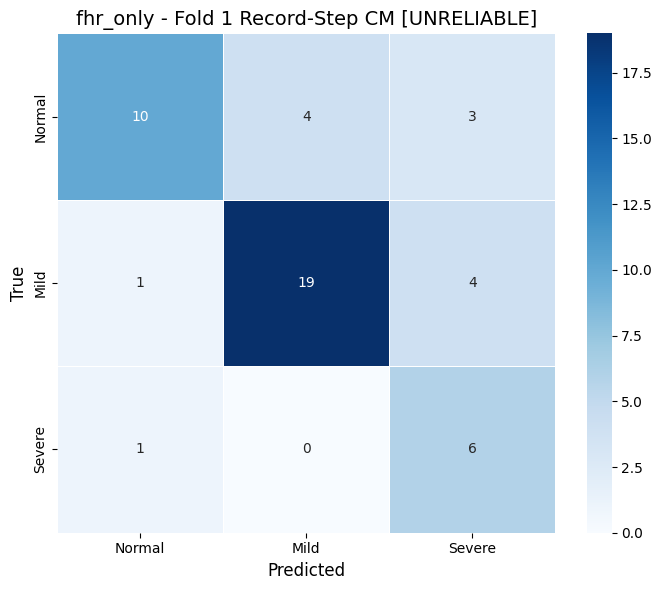


FOLD 2 / 10 - fhr_only
  Validation quality: UNRELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 10)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
155/156 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4871 - loss: 1.2952  val_record_step_balanced_accuracy: 0.3333
156/156 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.4775 - loss: 1.3239 - val_accuracy: 0.5000 - val_loss: 1.0486 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
155/156 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5078 - loss: 1.266

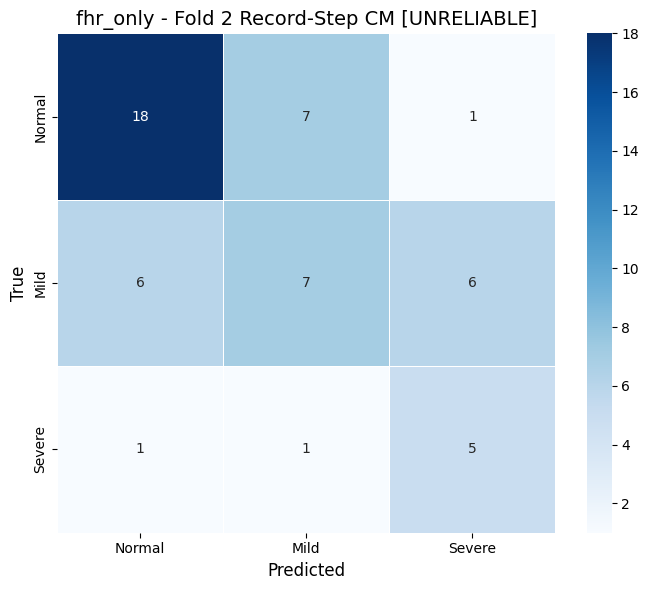


FOLD 3 / 10 - fhr_only
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 10)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3270 - loss: 1.3859  val_record_step_balanced_accuracy: 0.3333
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.4214 - loss: 1.3372 - val_accuracy: 0.4048 - val_loss: 1.0630 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
157/159 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5242 - loss: 1.3021

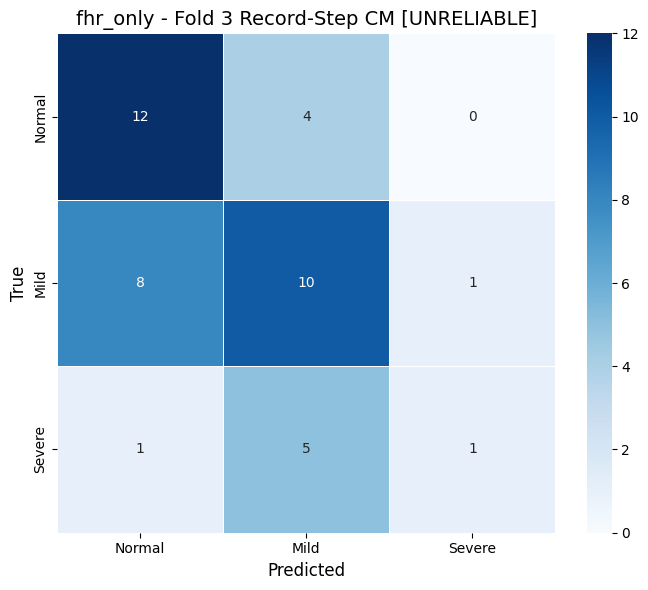


FOLD 4 / 10 - fhr_only
  Validation quality: UNRELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 10)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4253 - loss: 1.3442  val_record_step_balanced_accuracy: 0.3427
158/158 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.4600 - loss: 1.3359 - val_accuracy: 0.5407 - val_loss: 1.0507 - val_record_step_balanced_accuracy: 0.3427 - learning_rate: 0.0010
Epoch 2/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4627 - loss: 1.291

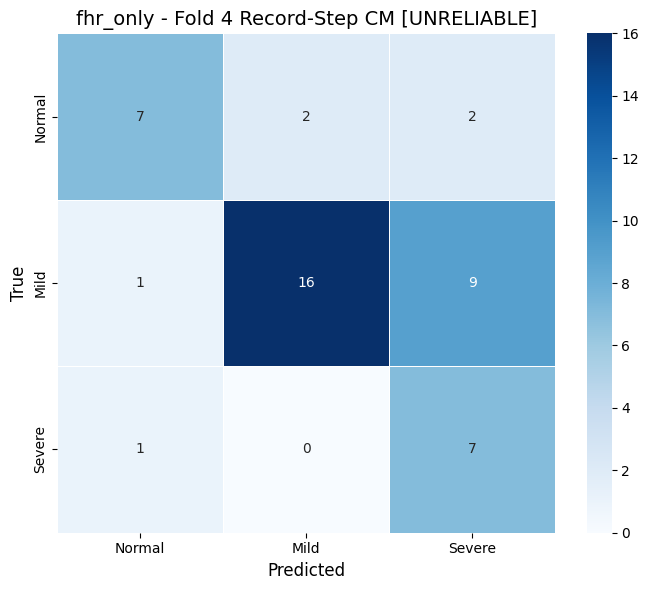


FOLD 5 / 10 - fhr_only
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4675 - loss: 1.3569  val_record_step_balanced_accuracy: 0.2937
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.4756 - loss: 1.3276 - val_accuracy: 0.4206 - val_loss: 1.0258 - val_record_step_balanced_accuracy: 0.2937 - learning_rate: 0.0010
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4993 - loss: 1.319

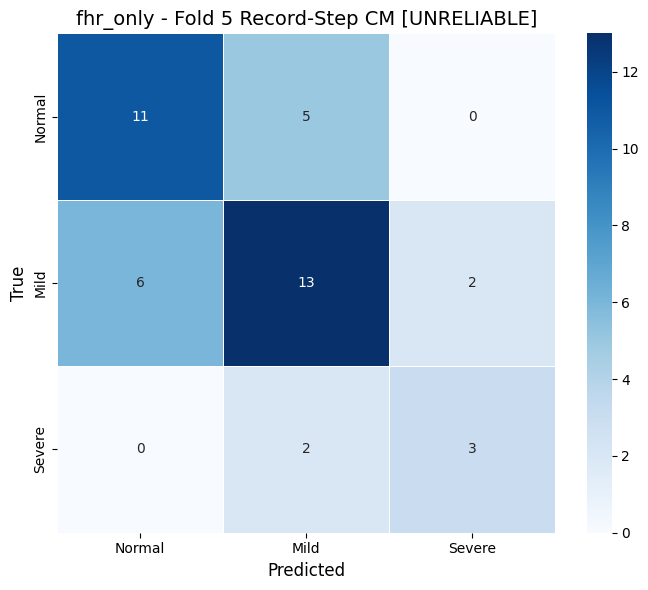


FOLD 6 / 10 - fhr_only
  Validation quality: UNRELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 10)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4630 - loss: 1.3486  val_record_step_balanced_accuracy: 0.3333
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.4840 - loss: 1.3325 - val_accuracy: 0.4800 - val_loss: 1.0578 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
155/156 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4977 - loss: 1.2939

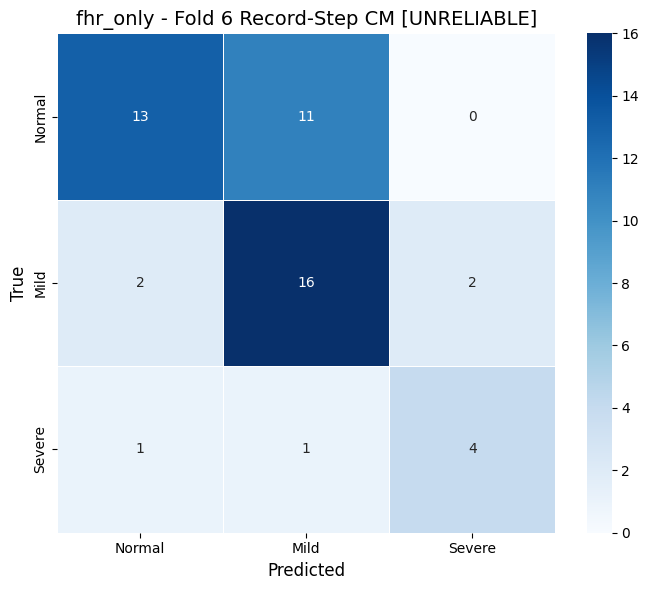


FOLD 7 / 10 - fhr_only
  Validation quality: UNRELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5096 - loss: 1.3569  val_record_step_balanced_accuracy: 0.3333
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.5087 - loss: 1.3247 - val_accuracy: 0.3261 - val_loss: 1.0666 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4974 - loss: 1.336

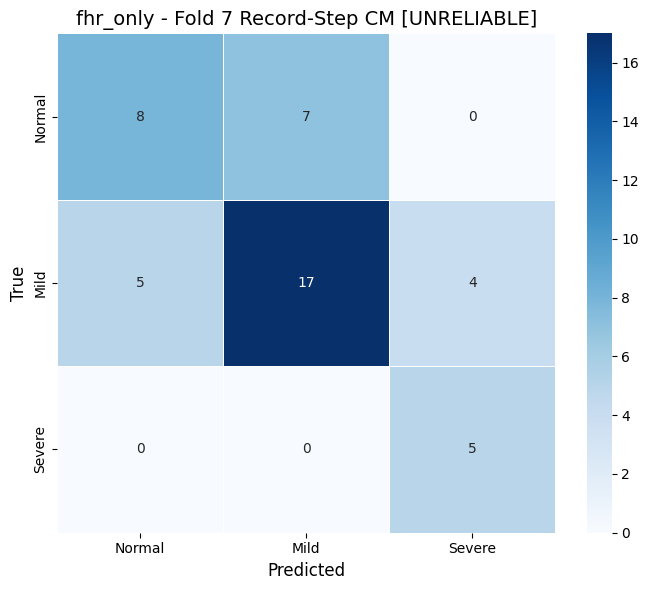


FOLD 8 / 10 - fhr_only
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 10)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
157/159 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4970 - loss: 1.3241  val_record_step_balanced_accuracy: 0.3485
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.4874 - loss: 1.3168 - val_accuracy: 0.3939 - val_loss: 1.0686 - val_record_step_balanced_accuracy: 0.3485 - learning_rate: 0.0010
Epoch 2/100
157/159 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5492 - loss: 1.281

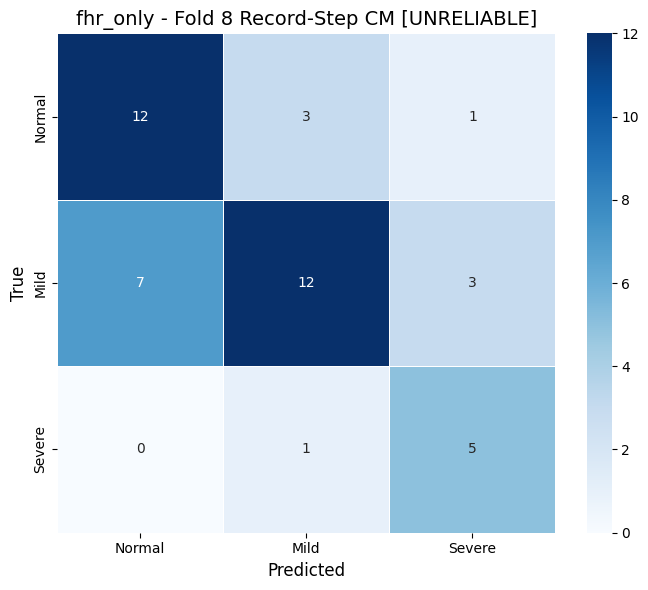


FOLD 9 / 10 - fhr_only
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 10)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
155/156 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4398 - loss: 1.3058  val_record_step_balanced_accuracy: 0.3333
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.4876 - loss: 1.3060 - val_accuracy: 0.4510 - val_loss: 1.0580 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5106 - loss: 1.278

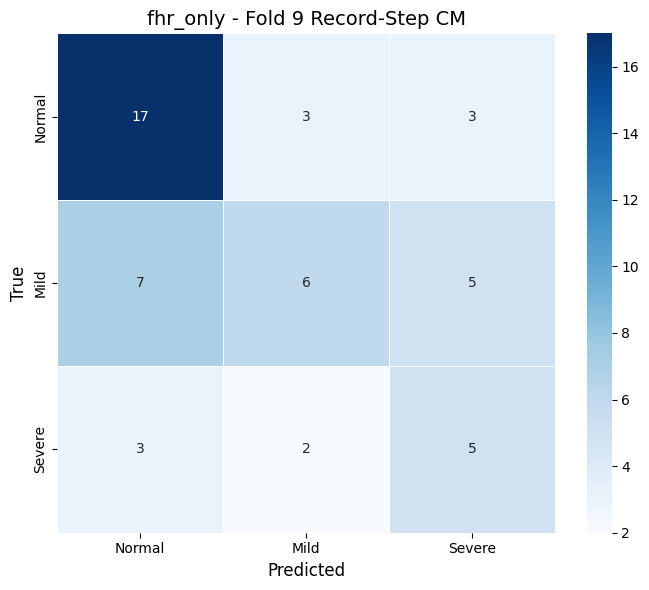


FOLD 10 / 10 - fhr_only
  Validation quality: UNRELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4505 - loss: 1.3623  val_record_step_balanced_accuracy: 0.3333
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.4833 - loss: 1.3432 - val_accuracy: 0.5217 - val_loss: 1.0442 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4763 - loss: 1.31

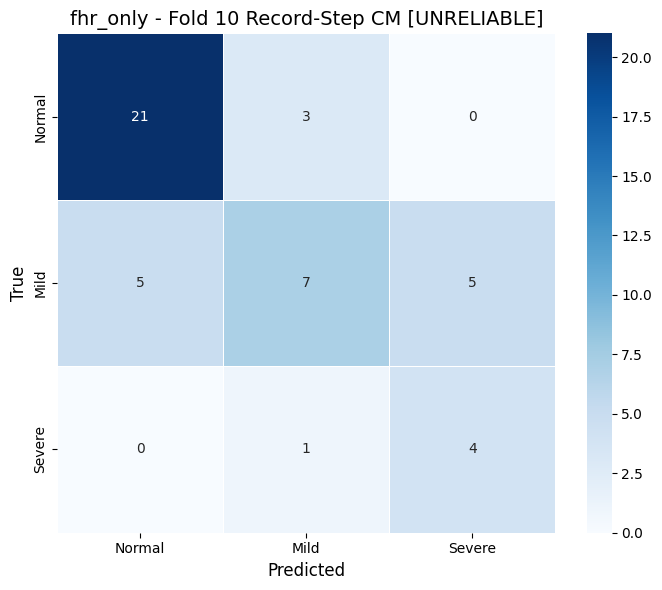


CROSS-VALIDATION SUMMARY (fhr_only)
  Reliable folds: 1 / 10 (threshold: 10 Severe step-units)
  accuracy              : 0.6379 +/- 0.0578
  balanced_accuracy     : 0.6483 +/- 0.0870
  macro_f1              : 0.6126 +/- 0.0730


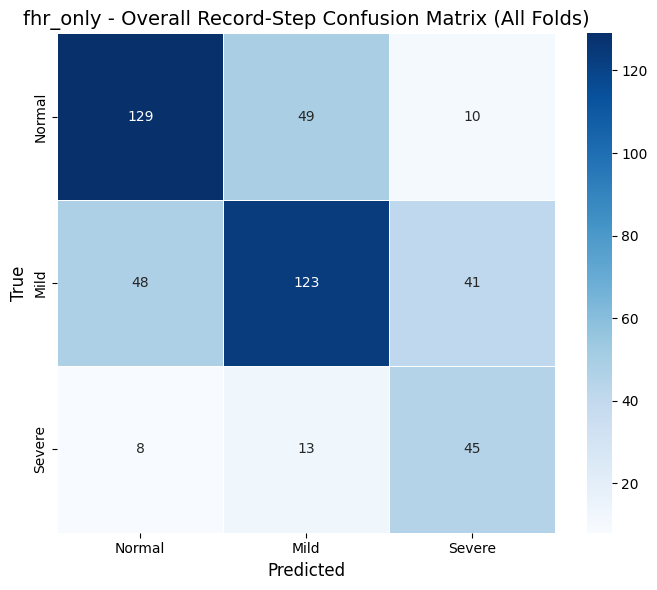

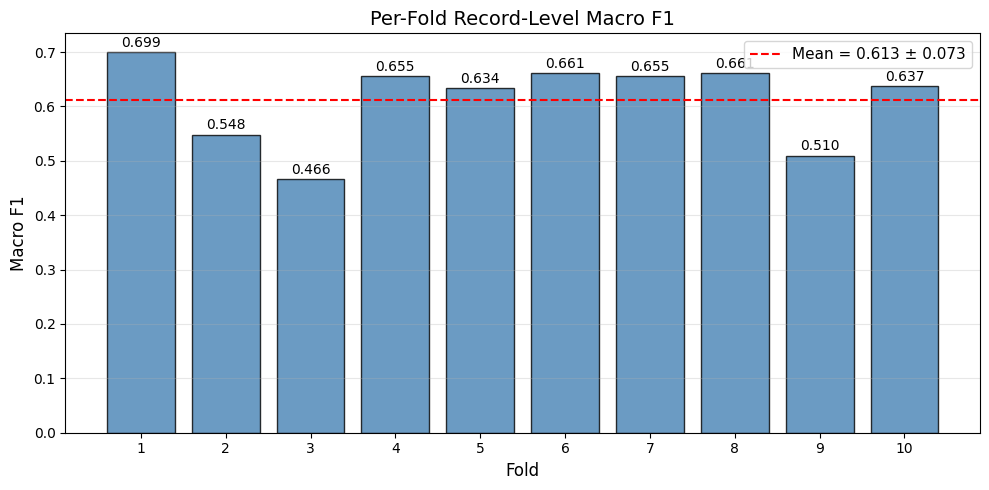

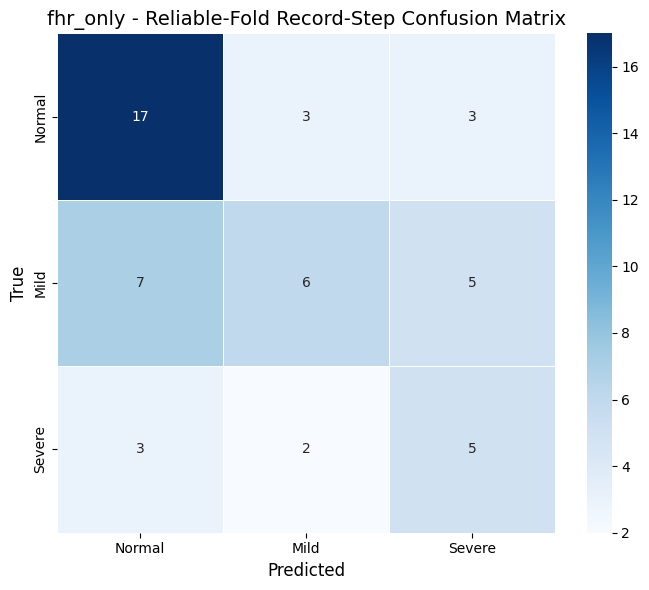


Saved summary JSON to outputs\fhr_only\results.json
Mean macro F1:          0.6126
Mean balanced accuracy: 0.6483
Mean Mild recall:       0.5665
Mean Severe recall:     0.6989

Running: Hybrid-Multi-Scale-CNN with FHR + UC
  Output directory: outputs\fhr_and_uc
  Signal channels:  2
  Clinical branch:  False
  Scratch batch:    8

Generating 10-fold CV for fhr_and_uc with 2 signal channel(s)...
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]

FOLD 1 / 10 - fhr_and_uc
  Validation quality: UNRELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 10)
  Train: 1254 windows from 299 records
  Val:   144 windows from 37 records / 48 record-steps
    Normal: train=513, val=51
    Mild: train=564, val=72
    Severe: train=177, val=21

TRAINING FROM 

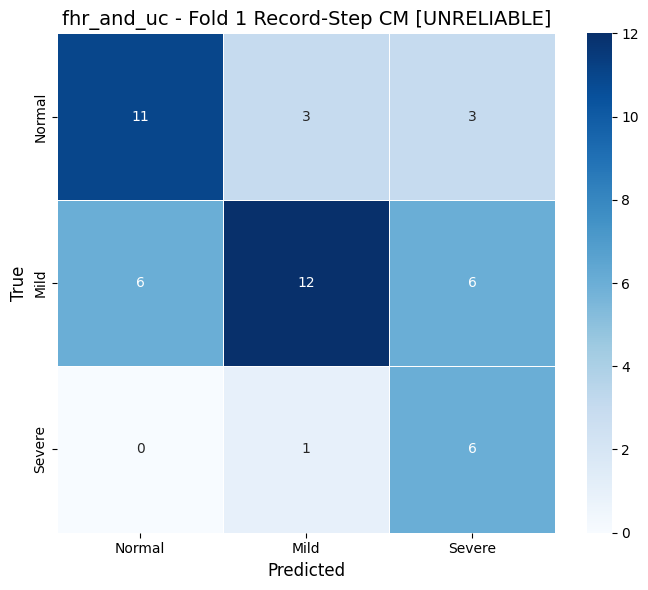


FOLD 2 / 10 - fhr_and_uc
  Validation quality: UNRELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 10)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
153/156 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4791 - loss: 1.3306  val_record_step_balanced_accuracy: 0.3333
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.4847 - loss: 1.3390 - val_accuracy: 0.3654 - val_loss: 1.0703 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
154/156 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5204 - loss: 1.2

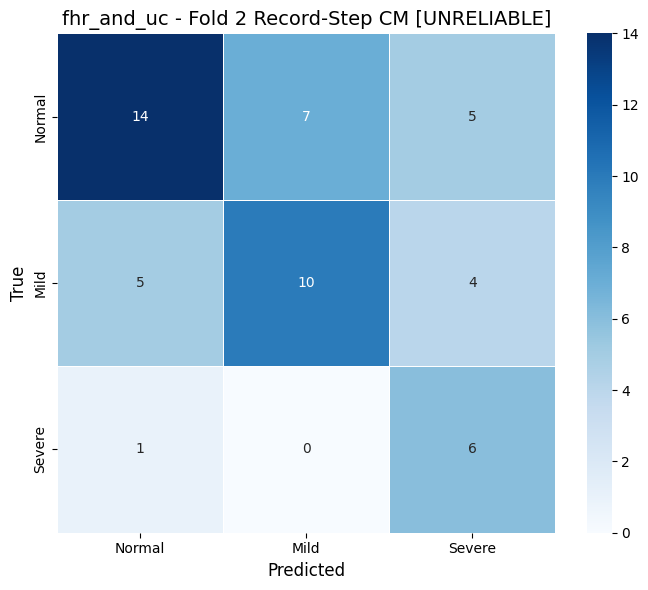


FOLD 3 / 10 - fhr_and_uc
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 10)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3437 - loss: 1.3713  val_record_step_balanced_accuracy: 0.3333
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.4088 - loss: 1.3344 - val_accuracy: 0.3810 - val_loss: 1.0669 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
157/159 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4968 - loss: 1.31

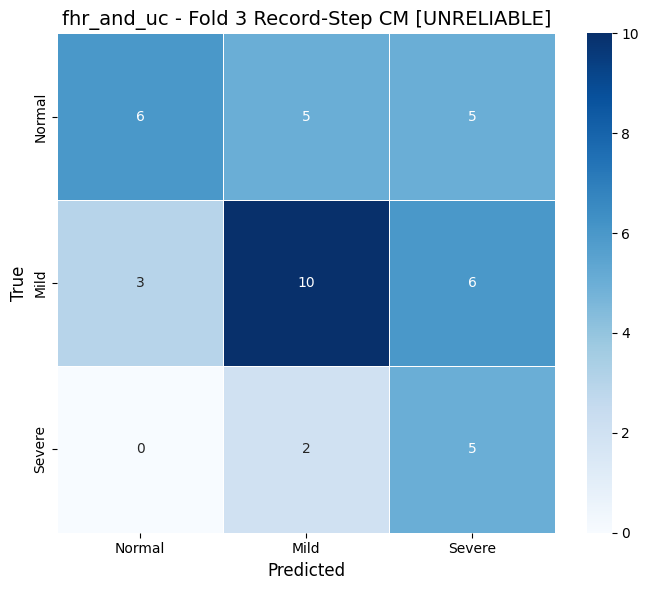


FOLD 4 / 10 - fhr_and_uc
  Validation quality: UNRELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 10)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5097 - loss: 1.3104  val_record_step_balanced_accuracy: 0.3333
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.5075 - loss: 1.3240 - val_accuracy: 0.5852 - val_loss: 1.0400 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4660 - loss: 1.27

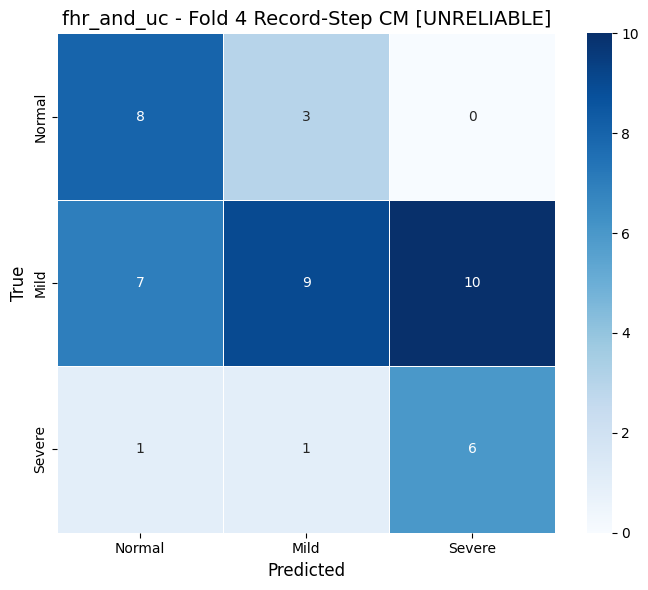


FOLD 5 / 10 - fhr_and_uc
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3224 - loss: 1.4119  val_record_step_balanced_accuracy: 0.3333
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.4143 - loss: 1.3595 - val_accuracy: 0.5000 - val_loss: 1.0230 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
158/159 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4945 - loss: 1.32

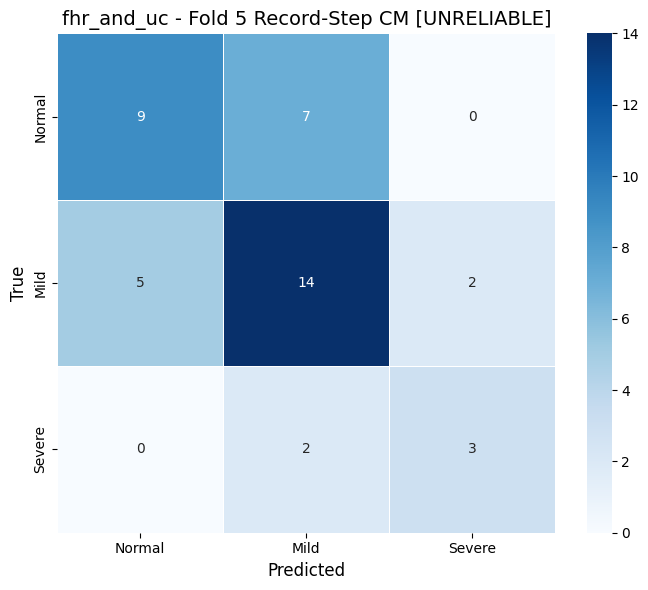


FOLD 6 / 10 - fhr_and_uc
  Validation quality: UNRELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 10)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
155/156 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4706 - loss: 1.3609  val_record_step_balanced_accuracy: 0.3611
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.4663 - loss: 1.3437 - val_accuracy: 0.4667 - val_loss: 1.0608 - val_record_step_balanced_accuracy: 0.3611 - learning_rate: 0.0010
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5013 - loss: 1.29

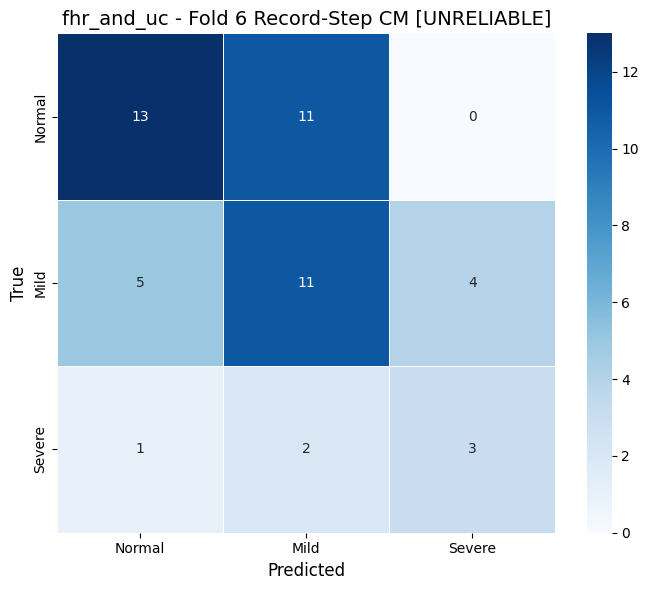


FOLD 7 / 10 - fhr_and_uc
  Validation quality: UNRELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2874 - loss: 1.3987  val_record_step_balanced_accuracy: 0.3333
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.3817 - loss: 1.3431 - val_accuracy: 0.3333 - val_loss: 1.0483 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4735 - loss: 1.33

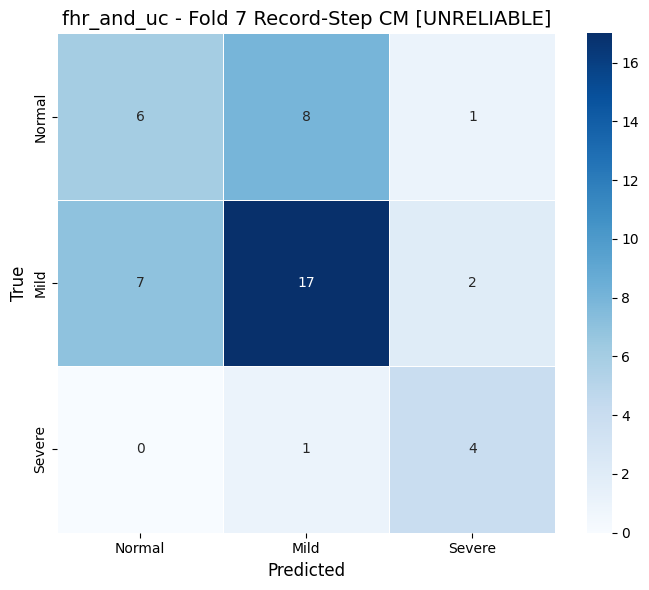


FOLD 8 / 10 - fhr_and_uc
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 10)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
158/159 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4633 - loss: 1.3301  val_record_step_balanced_accuracy: 0.3977
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.4771 - loss: 1.3164 - val_accuracy: 0.4697 - val_loss: 1.0407 - val_record_step_balanced_accuracy: 0.3977 - learning_rate: 0.0010
Epoch 2/100
158/159 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5059 - loss: 1.29

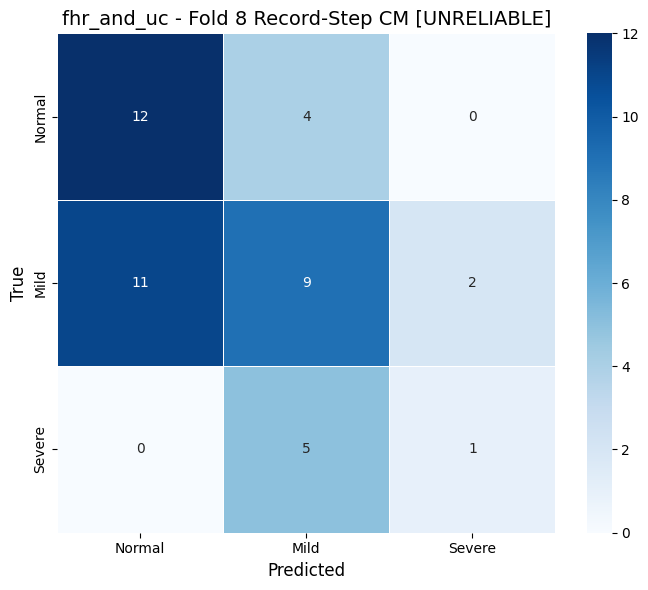


FOLD 9 / 10 - fhr_and_uc
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 10)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
154/156 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4551 - loss: 1.4243  val_record_step_balanced_accuracy: 0.3357
156/156 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.4771 - loss: 1.3712 - val_accuracy: 0.4052 - val_loss: 1.0795 - val_record_step_balanced_accuracy: 0.3357 - learning_rate: 0.0010
Epoch 2/100
154/156 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5420 - loss: 1.2

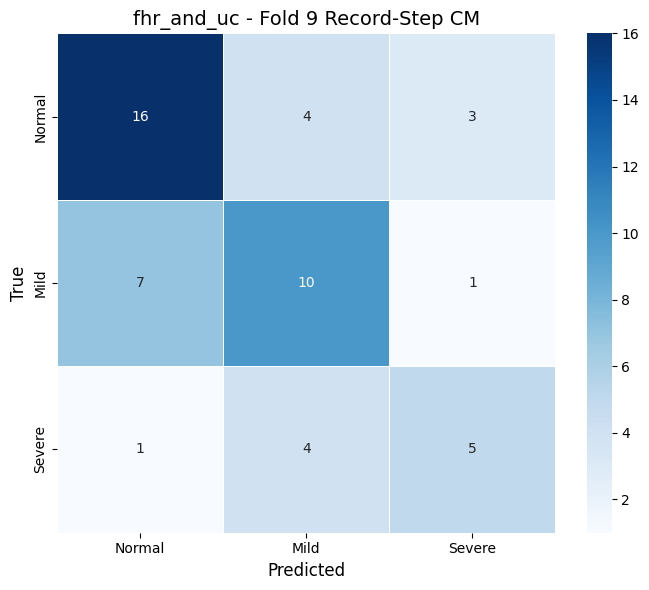


FOLD 10 / 10 - fhr_and_uc
  Validation quality: UNRELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 42 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4213 - loss: 1.4186  val_record_step_balanced_accuracy: 0.3333
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.4667 - loss: 1.3676 - val_accuracy: 0.3696 - val_loss: 1.0646 - val_record_step_balanced_accuracy: 0.3333 - learning_rate: 0.0010
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4977 - loss: 1.

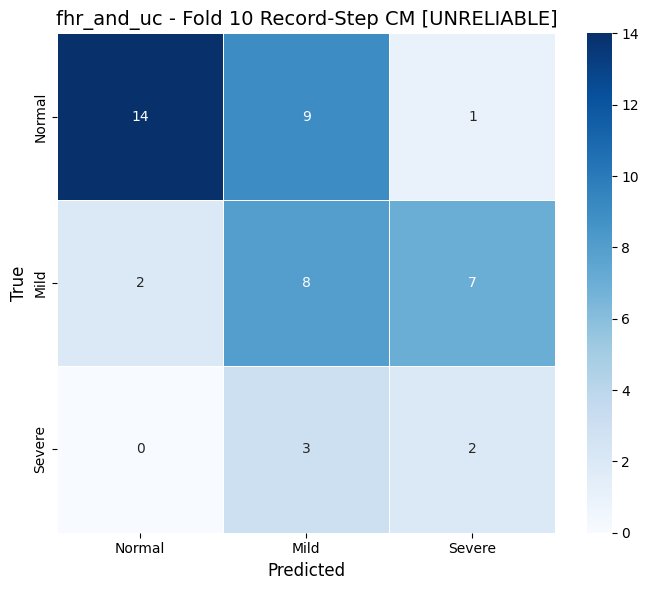


CROSS-VALIDATION SUMMARY (fhr_and_uc)
  Reliable folds: 1 / 10 (threshold: 10 Severe step-units)
  accuracy              : 0.5568 +/- 0.0448
  balanced_accuracy     : 0.5724 +/- 0.0680
  macro_f1              : 0.5376 +/- 0.0587


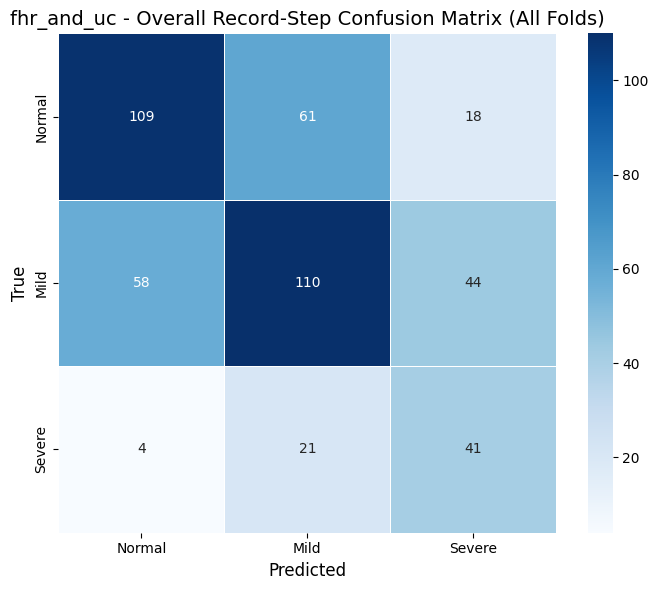

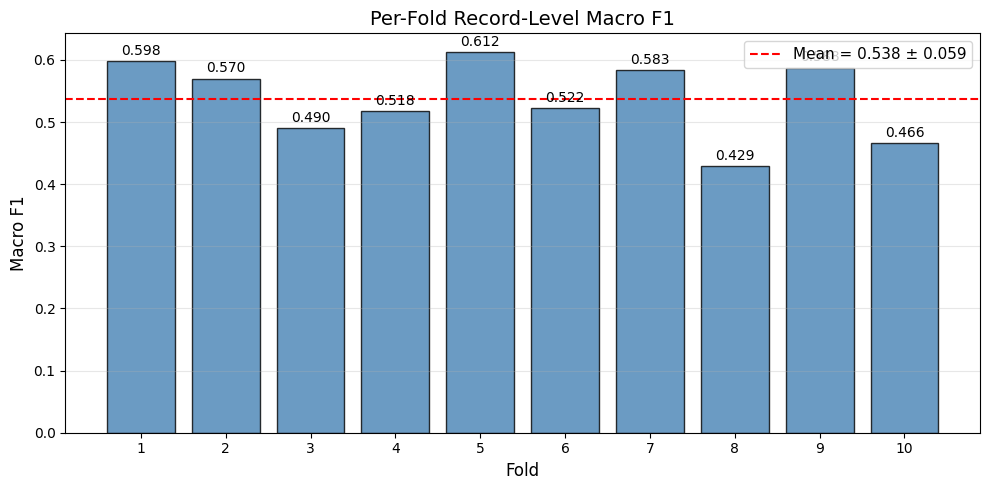

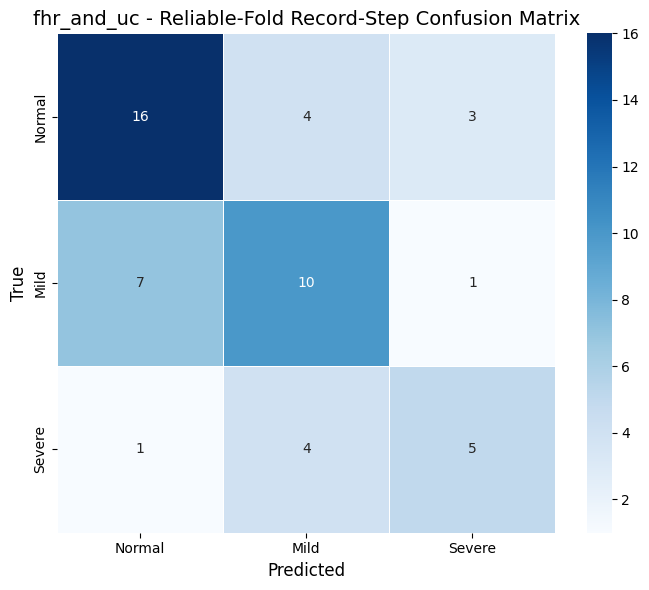


Saved summary JSON to outputs\fhr_and_uc\results.json
Mean macro F1:          0.5376
Mean balanced accuracy: 0.5724
Mean Mild recall:       0.5205
Mean Severe recall:     0.6145

Running: Hybrid-Multi-Scale-CNN with FHR + handcrafted FHR features
  Output directory: outputs\fhr_and_handcrafted_features
  Signal channels:  1
  Clinical branch:  True
  Scratch batch:    8
Computing engineered features from cleaned FHR windows for fhr_and_handcrafted_features...
  Engineered feature matrix: (1398, 10)

Generating 10-fold CV for fhr_and_handcrafted_features with 1 signal channel(s)...
  Total Severe step-units: 66, 10 folds -> max ~6/fold
  Found valid split at attempt 8 (seed=49, StratifiedGroupKFold)
    Severe step-units per val fold: [7, 7, 7, 8, 5, 6, 5, 6, 10, 5]

FOLD 1 / 10 - fhr_and_handcrafted_features
  Validation quality: UNRELIABLE
    Normal: 17 step-units, 51 windows
    Mild: 24 step-units, 72 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (thre

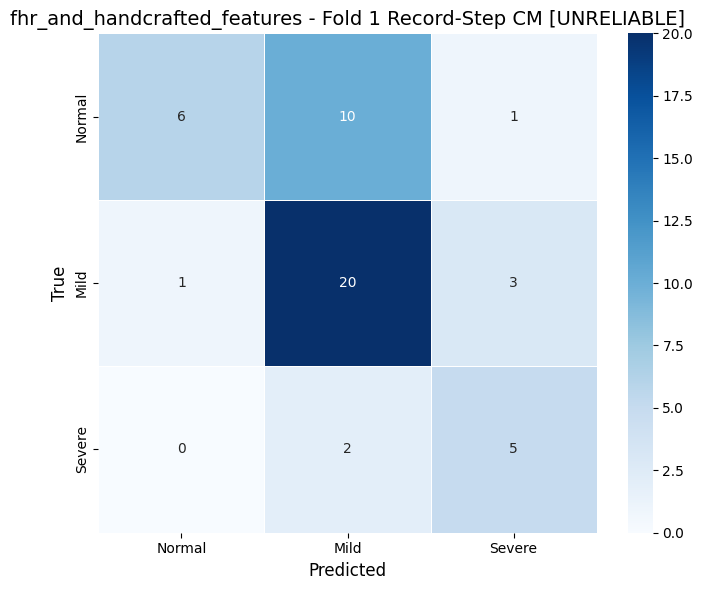


FOLD 2 / 10 - fhr_and_handcrafted_features
  Validation quality: UNRELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 10)
  Train: 1242 windows from 301 records
  Val:   156 windows from 35 records / 52 record-steps
    Normal: train=486, val=78
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4449 - loss: 1.3654  val_record_step_balanced_accuracy: 0.3273
156/156 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.4436 - loss: 1.3809 - val_accuracy: 0.4423 - val_loss: 1.0539 - val_record_step_balanced_accuracy: 0.3273 - learning_rate: 0.0010
Epoch 2/100
155/156 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 

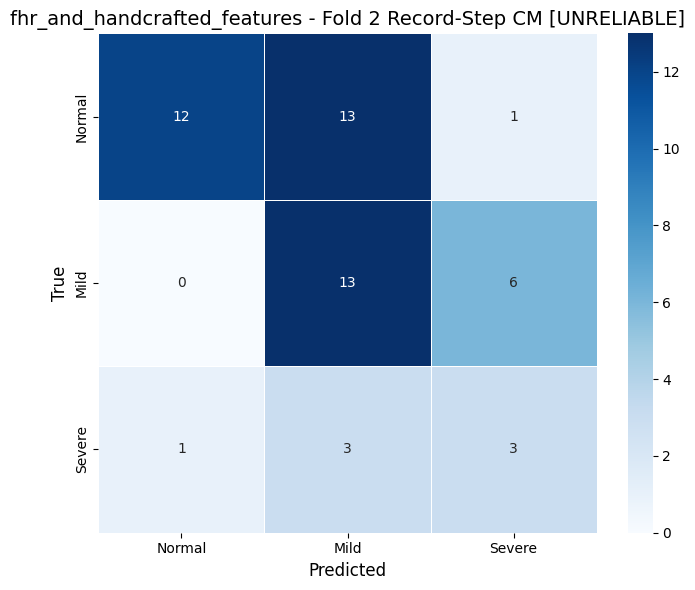


FOLD 3 / 10 - fhr_and_handcrafted_features
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows
  Severe step-units in val: 7 (threshold: 10)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=579, val=57
    Severe: train=177, val=21

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3677 - loss: 1.4259  val_record_step_balanced_accuracy: 0.3750
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.3884 - loss: 1.3855 - val_accuracy: 0.4762 - val_loss: 1.0581 - val_record_step_balanced_accuracy: 0.3750 - learning_rate: 0.0010
Epoch 2/100
157/159 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 

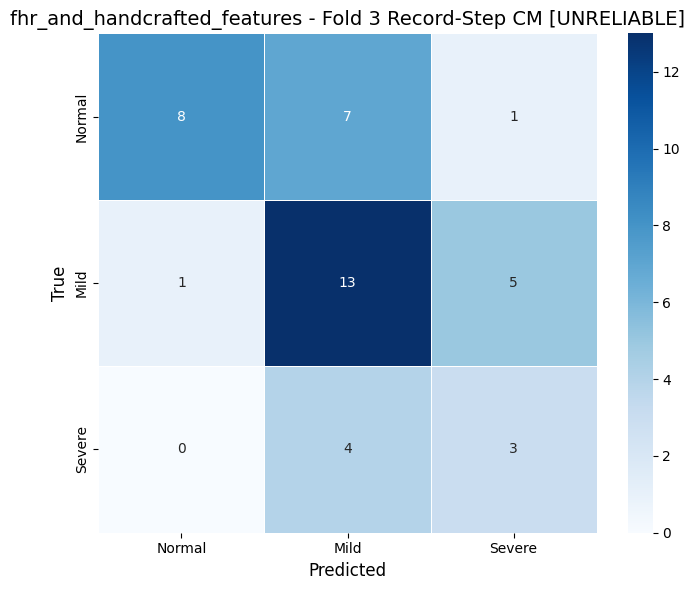


FOLD 4 / 10 - fhr_and_handcrafted_features
  Validation quality: UNRELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows
  Severe step-units in val: 8 (threshold: 10)
  Train: 1263 windows from 303 records
  Val:   135 windows from 33 records / 45 record-steps
    Normal: train=531, val=33
    Mild: train=558, val=78
    Severe: train=174, val=24

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
156/158 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4282 - loss: 1.3682  val_record_step_balanced_accuracy: 0.3648
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.4363 - loss: 1.3827 - val_accuracy: 0.5407 - val_loss: 1.0171 - val_record_step_balanced_accuracy: 0.3648 - learning_rate: 0.0010
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 

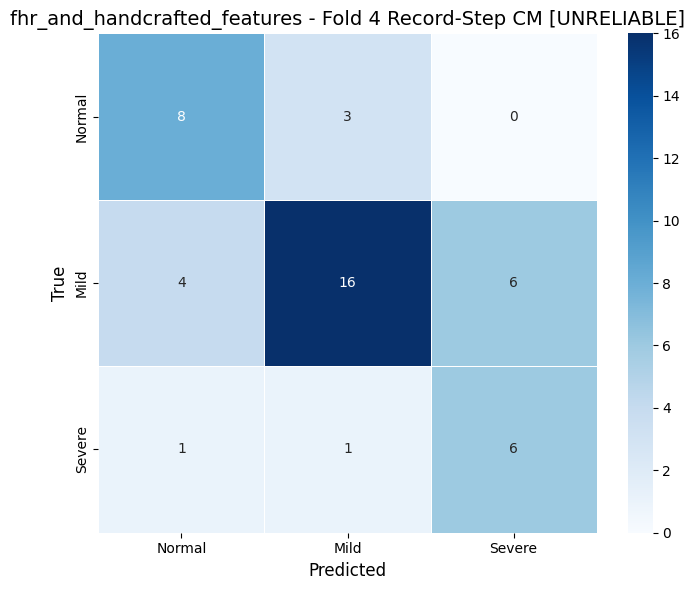


FOLD 5 / 10 - fhr_and_handcrafted_features
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1272 windows from 303 records
  Val:   126 windows from 33 records / 42 record-steps
    Normal: train=516, val=48
    Mild: train=573, val=63
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
158/159 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3775 - loss: 1.4141  val_record_step_balanced_accuracy: 0.4895
159/159 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.4119 - loss: 1.3821 - val_accuracy: 0.5238 - val_loss: 1.0173 - val_record_step_balanced_accuracy: 0.4895 - learning_rate: 0.0010
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 

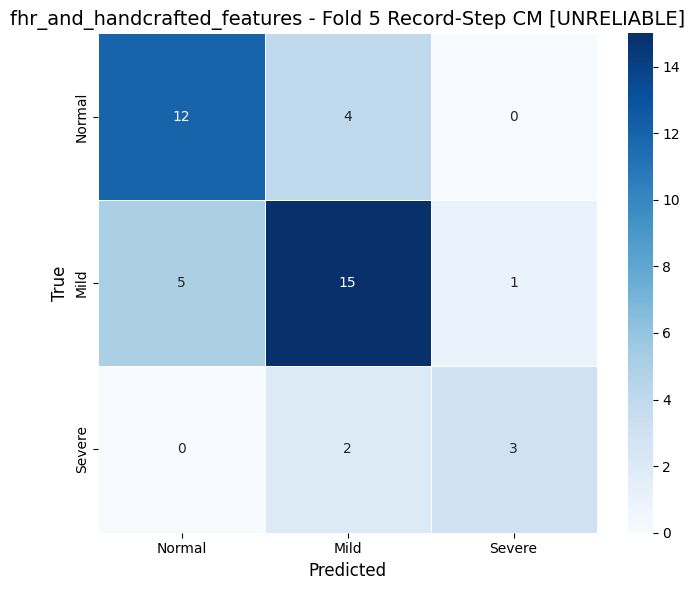


FOLD 6 / 10 - fhr_and_handcrafted_features
  Validation quality: UNRELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 20 step-units, 60 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 10)
  Train: 1248 windows from 301 records
  Val:   150 windows from 35 records / 50 record-steps
    Normal: train=492, val=72
    Mild: train=576, val=60
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3925 - loss: 1.4681  val_record_step_balanced_accuracy: 0.3306
156/156 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.4295 - loss: 1.4110 - val_accuracy: 0.4000 - val_loss: 1.0682 - val_record_step_balanced_accuracy: 0.3306 - learning_rate: 0.0010
Epoch 2/100
155/156 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 

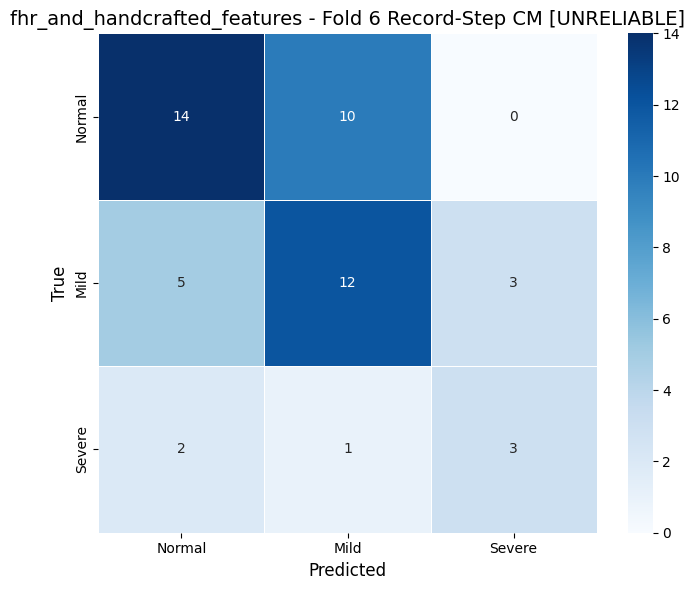


FOLD 7 / 10 - fhr_and_handcrafted_features
  Validation quality: UNRELIABLE
    Normal: 15 step-units, 45 windows
    Mild: 26 step-units, 78 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1260 windows from 304 records
  Val:   138 windows from 32 records / 46 record-steps
    Normal: train=519, val=45
    Mild: train=558, val=78
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3599 - loss: 1.5167  val_record_step_balanced_accuracy: 0.4026
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.4143 - loss: 1.4287 - val_accuracy: 0.5507 - val_loss: 1.0309 - val_record_step_balanced_accuracy: 0.4026 - learning_rate: 0.0010
Epoch 2/100
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 

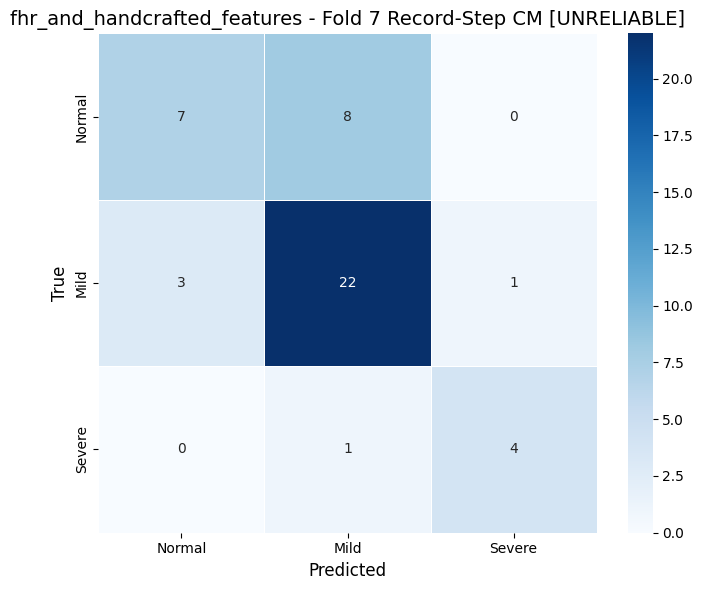


FOLD 8 / 10 - fhr_and_handcrafted_features
  Validation quality: UNRELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 22 step-units, 66 windows
    Severe: 6 step-units, 18 windows
  Severe step-units in val: 6 (threshold: 10)
  Train: 1266 windows from 305 records
  Val:   132 windows from 31 records / 44 record-steps
    Normal: train=516, val=48
    Mild: train=570, val=66
    Severe: train=180, val=18

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
158/159 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4730 - loss: 1.3891  val_record_step_balanced_accuracy: 0.3851
159/159 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.4724 - loss: 1.3660 - val_accuracy: 0.4848 - val_loss: 1.0281 - val_record_step_balanced_accuracy: 0.3851 - learning_rate: 0.0010
Epoch 2/100
157/159 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 

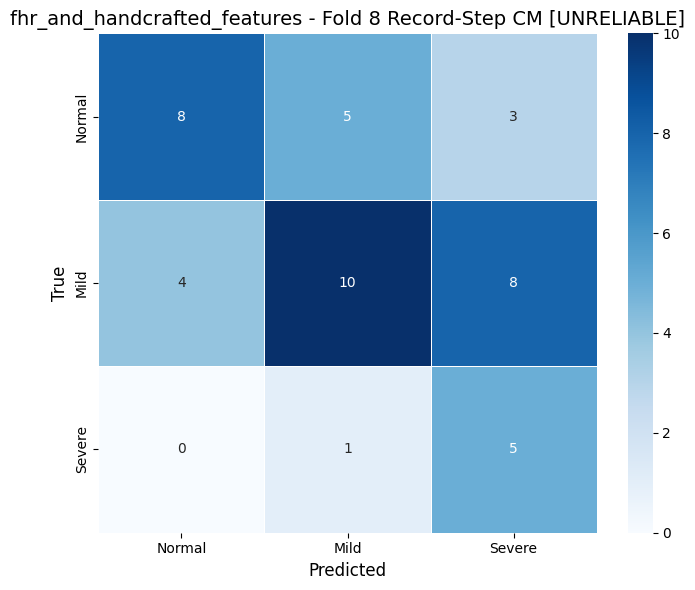


FOLD 9 / 10 - fhr_and_handcrafted_features
  Validation quality: RELIABLE
    Normal: 23 step-units, 69 windows
    Mild: 18 step-units, 54 windows
    Severe: 10 step-units, 30 windows
  Severe step-units in val: 10 (threshold: 10)
  Train: 1245 windows from 303 records
  Val:   153 windows from 33 records / 51 record-steps
    Normal: train=495, val=69
    Mild: train=582, val=54
    Severe: train=168, val=30

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
154/156 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5299 - loss: 1.4095  val_record_step_balanced_accuracy: 0.4282
156/156 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.5141 - loss: 1.3803 - val_accuracy: 0.4967 - val_loss: 1.0459 - val_record_step_balanced_accuracy: 0.4282 - learning_rate: 0.0010
Epoch 2/100
155/156 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 

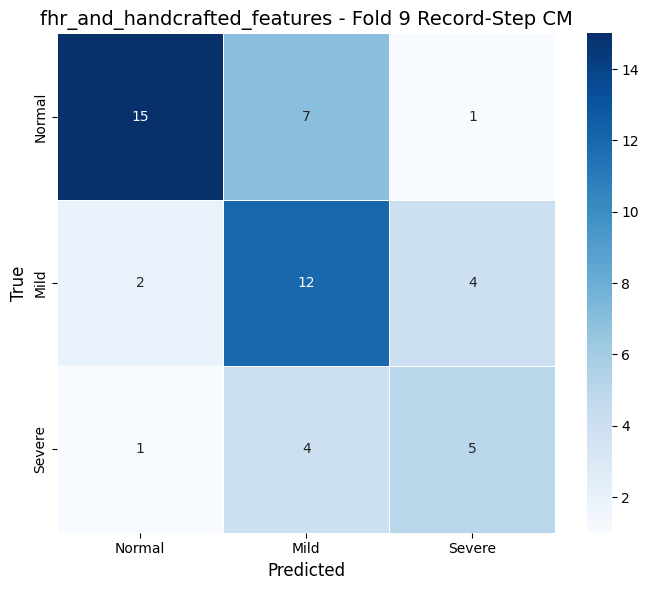


FOLD 10 / 10 - fhr_and_handcrafted_features
  Validation quality: UNRELIABLE
    Normal: 24 step-units, 72 windows
    Mild: 17 step-units, 51 windows
    Severe: 5 step-units, 15 windows
  Severe step-units in val: 5 (threshold: 10)
  Train: 1260 windows from 302 records
  Val:   138 windows from 34 records / 46 record-steps
    Normal: train=492, val=72
    Mild: train=585, val=51
    Severe: train=183, val=15

TRAINING FROM SCRATCH
  All 48 layers set to trainable
  Class weights (manual override): {0: 0.9, 1: 1.2, 2: 2.5}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.05
Epoch 1/100
156/158 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3664 - loss: 1.4499  val_record_step_balanced_accuracy: 0.5145
158/158 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.4103 - loss: 1.4194 - val_accuracy: 0.5072 - val_loss: 1.0279 - val_record_step_balanced_accuracy: 0.5145 - learning_rate: 0.0010
Epoch 2/100
155/158 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy:

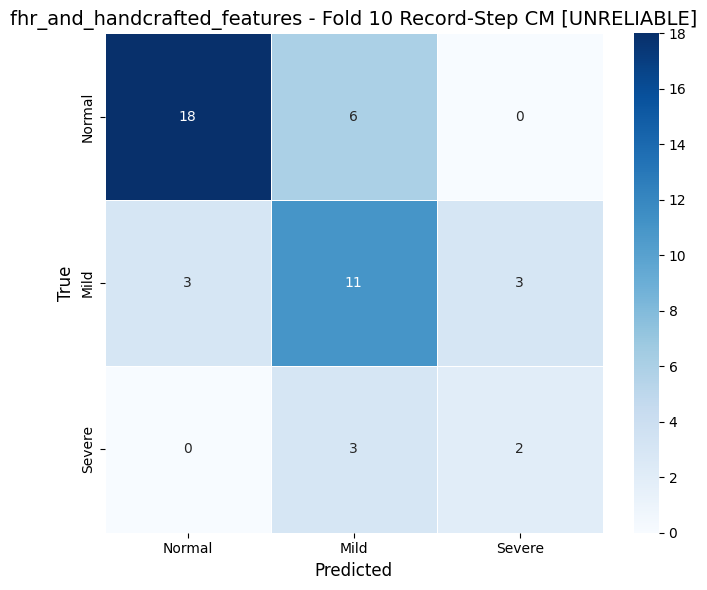


CROSS-VALIDATION SUMMARY (fhr_and_handcrafted_features)
  Reliable folds: 1 / 10 (threshold: 10 Severe step-units)
  accuracy              : 0.6258 +/- 0.0663
  balanced_accuracy     : 0.6148 +/- 0.0618
  macro_f1              : 0.6005 +/- 0.0688


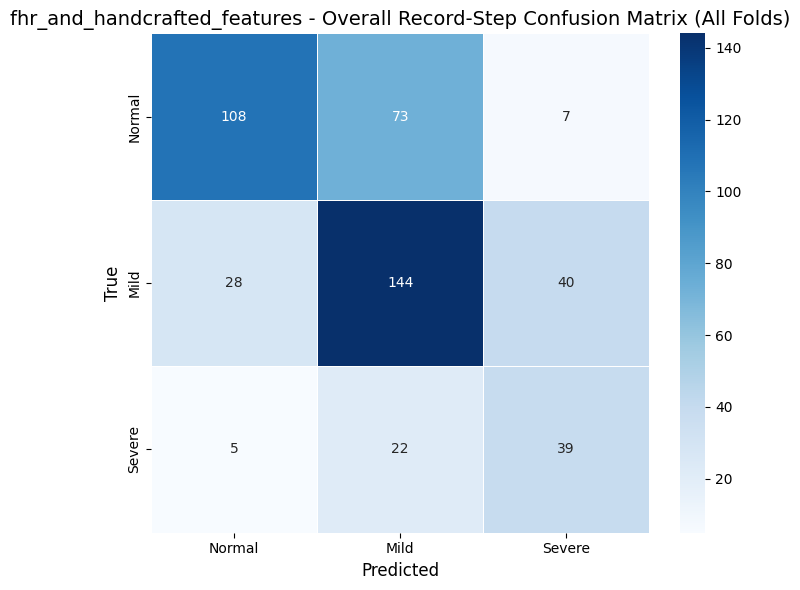

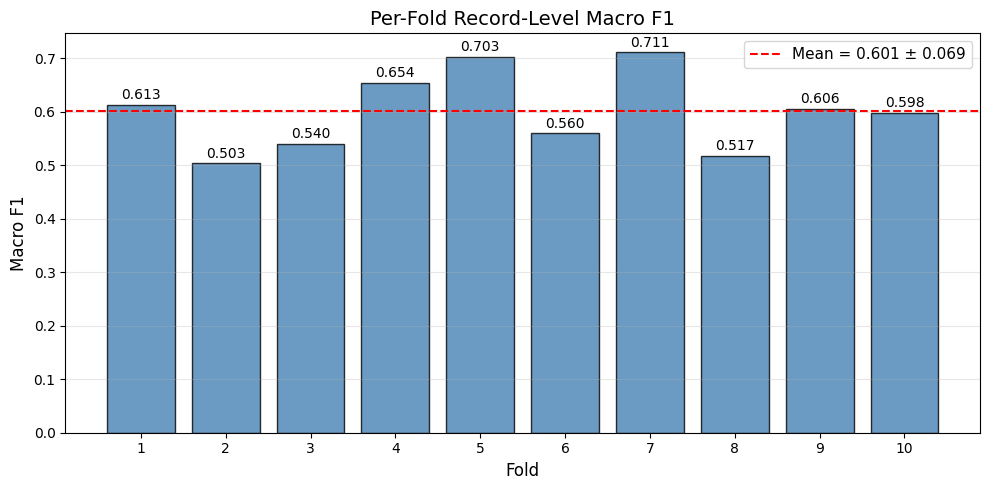

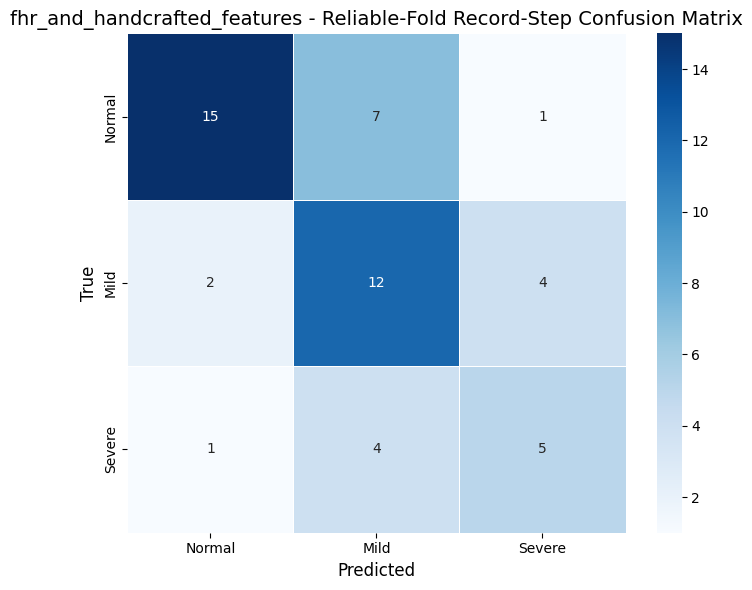


Saved summary JSON to outputs\fhr_and_handcrafted_features\results.json
Mean macro F1:          0.6005
Mean balanced accuracy: 0.6148
Mean Mild recall:       0.6746
Mean Severe recall:     0.5955

########################################################################
Completed the three saved runs:
  - Hybrid-Multi-Scale-CNN with FHR only -> outputs\fhr_only
  - Hybrid-Multi-Scale-CNN with FHR + UC -> outputs\fhr_and_uc
  - Hybrid-Multi-Scale-CNN with FHR + handcrafted FHR features -> outputs\fhr_and_handcrafted_features
########################################################################


In [ ]:
def run_input_experiment(spec: dict) -> Tuple[List[dict], dict]:
    global OUTPUT_DIR

    run_output_dir = Path(spec['output_dir'])
    run_output_dir.mkdir(parents=True, exist_ok=True)

    cfg_run = dict(CFG)
    cfg_run['use_clinical_features'] = bool(spec['use_clinical_features'])

    X_run = build_signal_tensor(
        X_fhr_all,
        X_uc_all,
        include_uc=bool(spec['include_uc']),
    )

    batch_candidates = []
    candidate = ablation_base_batch
    while candidate >= 2:
        batch_candidates.append(candidate)
        candidate //= 2
    batch_candidates = list(dict.fromkeys(batch_candidates))

    prev_output_dir = OUTPUT_DIR
    fold_results = None
    last_error = None

    for batch_size in batch_candidates:
        cfg_run['scratch_batch'] = int(batch_size)
        OUTPUT_DIR = run_output_dir
        try:
            tf.keras.backend.clear_session()
            gc.collect()

            print("\n" + "=" * 72)
            print(f"Running: {spec['name']}")
            print(f"  Output directory: {run_output_dir}")
            print(f"  Signal channels:  {X_run.shape[-1]}")
            print(f"  Clinical branch:  {cfg_run['use_clinical_features']}")
            print(f"  Scratch batch:    {cfg_run['scratch_batch']}")
            print("=" * 72)

            fold_results = run_grouped_cv_input_variant(
                X=X_run,
                y=y_all,
                groups=groups_all,
                metadata=meta_all,
                cfg=cfg_run,
                X_raw=X_fhr_all,
                feature_missing_frac=meta_all['missing_frac_prefill'].to_numpy(dtype=np.float32),
                input_variant=spec['slug'],
            )
            last_error = None
            break
        except (tf.errors.ResourceExhaustedError, MemoryError) as exc:
            last_error = exc
            print(
                f"\nResource exhaustion with scratch_batch={batch_size} for {spec['slug']}. "
                "Clearing session and retrying with a smaller batch."
            )
            tf.keras.backend.clear_session()
            gc.collect()
        finally:
            OUTPUT_DIR = prev_output_dir

    if fold_results is None:
        raise last_error

    summary = build_experiment_summary(
        spec=spec,
        fold_results=fold_results,
        X_run=X_run,
        manual_weights=manual_class_weights,
        cfg_run=cfg_run,
        groups_all=groups_all,
        meta_all=meta_all,
    )

    with open(run_output_dir / "results.json", 'w') as f:
        json.dump(summary, f, indent=2, default=str)

    print(f"\nSaved summary JSON to {run_output_dir / 'results.json'}")
    print(f"Mean macro F1:          {summary['mean_macro_f1']:.4f}")
    print(f"Mean balanced accuracy: {summary['mean_balanced_acc']:.4f}")
    print(f"Mean Mild recall:       {summary['mean_recall_Mild']:.4f}")
    print(f"Mean Severe recall:     {summary['mean_recall_Severe']:.4f}")

    return fold_results, summary


experiment_results = {}
experiment_summaries = {}

try:
    compute_class_weights_from_y = _manual_class_weight_resolver_factory(manual_class_weights)
    for spec in INPUT_COMPARISON_RUNS:
        fold_results, summary = run_input_experiment(spec)
        experiment_results[spec['slug']] = fold_results
        experiment_summaries[spec['slug']] = summary
finally:
    compute_class_weights_from_y = _original_compute_class_weights_from_y

print("\n" + "#" * 72)
print("Completed the input ablation runs:")
for spec in INPUT_COMPARISON_RUNS:
    print(f"  - {spec['name']} -> {spec['output_dir']}")
print("#" * 72)

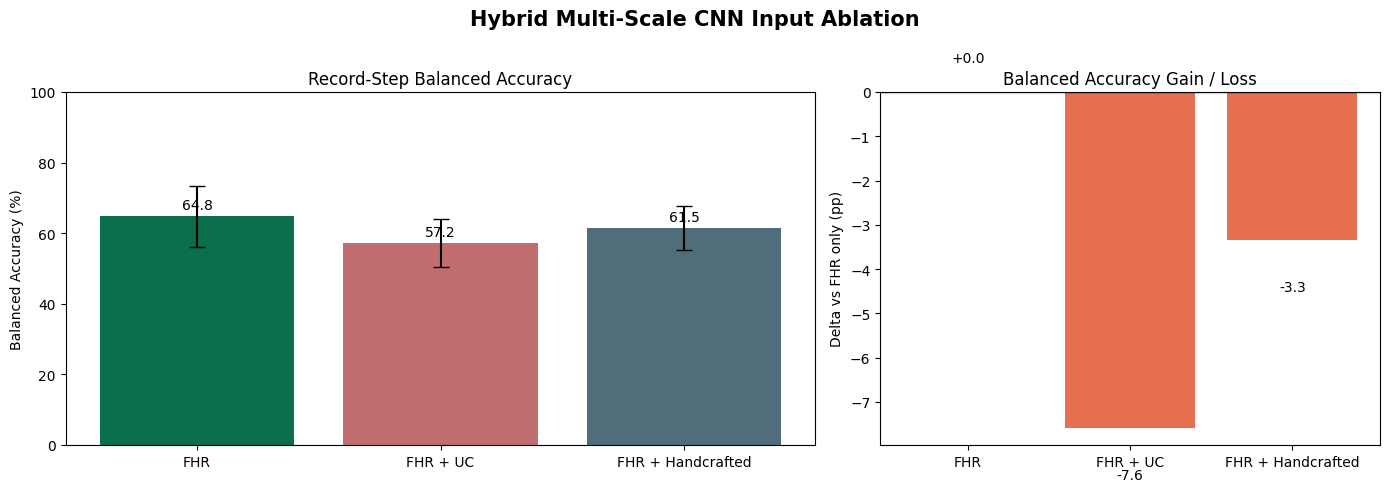

Saved comparison outputs:
  CSV:  outputs\input_comparison\balanced_accuracy_comparison.csv
  JSON: outputs\input_comparison\balanced_accuracy_comparison.json
  PNG:  outputs\input_comparison\balanced_accuracy_comparison.png

Balanced accuracy comparison:
                                          experiment  balanced_accuracy_pct  \
0               Hybrid-Multi-Scale-CNN with FHR only              64.826858   
1               Hybrid-Multi-Scale-CNN with FHR + UC              57.235721   
2  Hybrid-Multi-Scale-CNN with FHR + handcrafted ...              61.481792   

   balanced_accuracy_delta_pct  
0                     0.000000  
1                    -7.591136  
2                    -3.345065  


In [ ]:
comparison_output_dir = OUTPUT_ROOT / "input_comparison"
comparison_output_dir.mkdir(parents=True, exist_ok=True)

comparison_rows = []
for spec in INPUT_COMPARISON_RUNS:
    results_path = Path(spec['output_dir']) / "results.json"
    if not results_path.exists():
        print(f"Missing results file, skipping: {results_path}")
        continue

    with open(results_path, 'r') as f:
        result = json.load(f)

    comparison_rows.append({
        'experiment': spec['name'],
        'slug': spec['slug'],
        'signal_channels': int(result.get('n_signal_channels', 1)),
        'use_clinical_features': bool(result.get('use_clinical_features', False)),
        'mean_macro_f1': float(result['mean_macro_f1']),
        'std_macro_f1': float(result['std_macro_f1']),
        'mean_balanced_acc': float(result['mean_balanced_acc']),
        'std_balanced_acc': float(result['std_balanced_acc']),
        'mean_accuracy': float(result['mean_accuracy']),
        'std_accuracy': float(result['std_accuracy']),
        'mean_recall_Normal': float(result['mean_recall_Normal']),
        'mean_recall_Mild': float(result['mean_recall_Mild']),
        'mean_recall_Severe': float(result['mean_recall_Severe']),
        'results_json': str(results_path),
    })

comparison_df = pd.DataFrame(comparison_rows)
if comparison_df.empty:
    raise FileNotFoundError("No results.json files found in the configured ablation output folders.")

order = [spec['name'] for spec in INPUT_COMPARISON_RUNS if spec['name'] in comparison_df['experiment'].tolist()]
comparison_df['experiment'] = pd.Categorical(comparison_df['experiment'], categories=order, ordered=True)
comparison_df = comparison_df.sort_values('experiment').reset_index(drop=True)

baseline_slug = 'fhr_only'
if baseline_slug not in comparison_df['slug'].tolist():
    baseline_slug = comparison_df.loc[0, 'slug']

baseline_bal_acc = float(
    comparison_df.loc[comparison_df['slug'] == baseline_slug, 'mean_balanced_acc'].iloc[0]
)
comparison_df['balanced_accuracy_pct'] = comparison_df['mean_balanced_acc'] * 100.0
comparison_df['balanced_accuracy_delta_pct'] = (comparison_df['mean_balanced_acc'] - baseline_bal_acc) * 100.0

comparison_csv = comparison_output_dir / 'balanced_accuracy_comparison.csv'
comparison_json = comparison_output_dir / 'balanced_accuracy_comparison.json'
comparison_png = comparison_output_dir / 'balanced_accuracy_comparison.png'

comparison_df.to_csv(comparison_csv, index=False)
with open(comparison_json, 'w') as f:
    json.dump(comparison_df.to_dict(orient='records'), f, indent=2)

labels = [
    'FHR',
    'FHR + UC',
]
colors = ['#0B6E4F', '#C16E70']
delta_colors = []
for delta in comparison_df['balanced_accuracy_delta_pct']:
    if abs(delta) < 1e-8:
        delta_colors.append('#6C757D')
    elif delta > 0:
        delta_colors.append('#2A9D8F')
    else:
        delta_colors.append('#E76F51')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.5, 1.0]})

x = np.arange(len(comparison_df))
axes[0].bar(
    x,
    comparison_df['balanced_accuracy_pct'],
    yerr=comparison_df['std_balanced_acc'] * 100.0,
    color=colors[:len(comparison_df)],
    capsize=6,
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels[:len(comparison_df)], rotation=0)
axes[0].set_ylabel('Balanced Accuracy (%)')
axes[0].set_title('Record-Step Balanced Accuracy')
axes[0].set_ylim(0, max(100, comparison_df['balanced_accuracy_pct'].max() + 10))
for idx, value in enumerate(comparison_df['balanced_accuracy_pct']):
    axes[0].text(idx, value + 1.2, f"{value:.1f}", ha='center', va='bottom', fontsize=10)

axes[1].axhline(0.0, color='black', linewidth=1.0, alpha=0.7)
axes[1].bar(
    x,
    comparison_df['balanced_accuracy_delta_pct'],
    color=delta_colors,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels[:len(comparison_df)], rotation=0)
axes[1].set_ylabel('Delta vs FHR only (pp)')
axes[1].set_title('Balanced Accuracy Gain / Loss')
for idx, value in enumerate(comparison_df['balanced_accuracy_delta_pct']):
    offset = 0.6 if value >= 0 else -0.9
    va = 'bottom' if value >= 0 else 'top'
    axes[1].text(idx, value + offset, f"{value:+.1f}", ha='center', va=va, fontsize=10)

fig.suptitle('Hybrid Multi-Scale CNN Input Ablation', fontsize=15, fontweight='bold')
fig.tight_layout()
fig.savefig(comparison_png, dpi=300, bbox_inches='tight')
plt.show()

print("Saved comparison outputs:")
print(f"  CSV:  {comparison_csv}")
print(f"  JSON: {comparison_json}")
print(f"  PNG:  {comparison_png}")
print("\nBalanced accuracy comparison:")
print(comparison_df[['experiment', 'balanced_accuracy_pct', 'balanced_accuracy_delta_pct']])